# Introduction to Axes (or Subplots)

<img src="img/anatomy.png" alt="Anatomy of Axes" style="width:70vw;">

## Creating Axes

Text(0.5, 0.98, 'plt.subplots()')

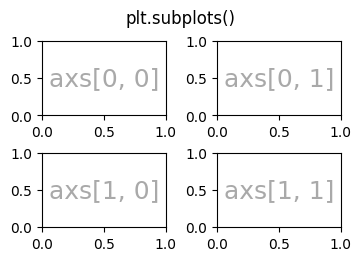

In [1]:
import matplotlib.pyplot as plt
import matplotlib.scale as mscale
from matplotlib.ticker import FixedLocator, NullFormatter
import matplotlib as mpl
import numpy as np
from numpy import pi, sin

# PI = np.pi
# sin = np.sin

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(3.5, 2.5), layout="constrained")

# For each Axes, add an artist, in this case a nice label in the middle.
for row in range(2):
    for col in range(2):
        axs[row, col].annotate(
            f"axs[{row}, {col}]",
            (0.5, 0.5),
            transform=axs[row, col].transAxes,
            ha="center",
            va="center",
            fontsize=18,
            color="darkgrey",
        )

fig.suptitle("plt.subplots()")

## Axes Plotting Methods

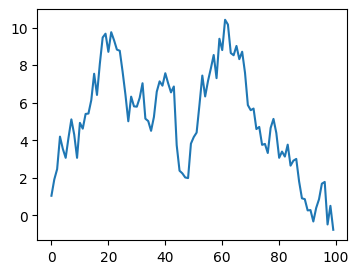

In [2]:
fig, ax = plt.subplots(figsize=(4, 3))

np.random.seed(19680801)
t = np.arange(100)
x = np.cumsum(np.random.randn(100))
lines = ax.plot(t, x)

## Axes Labelling and Annotation

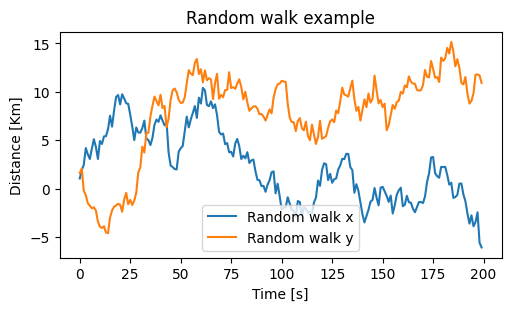

In [3]:
fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")

np.random.seed(19680801)
t = np.arange(200)
x = np.cumsum(np.random.randn(200))
y = np.cumsum(np.random.randn(200))
linesx = ax.plot(t, x, label="Random walk x")
linesy = ax.plot(t, y, label="Random walk y")

ax.set_xlabel("Time [s]")
ax.set_ylabel("Distance [Km]")
ax.set_title("Random walk example")
ax.legend()
plt.show()

## Axes Limits, Scales and Ticking

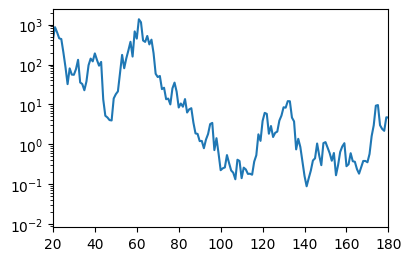

In [4]:
# An Axis with a logarithmic scale
fig, ax = plt.subplots(figsize=(4, 2.5), layout="constrained")

np.random.seed(19680801)
t = np.arange(200)
x = 2 ** np.cumsum(np.random.randn(200))
linesx = ax.plot(t, x)
ax.set_yscale("log")
ax.set_xlim([20, 180])

plt.show()

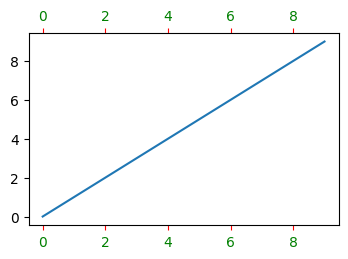

In [5]:
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(np.arange(10))

ax.tick_params(top=True, labeltop=True, color="red", axis="x", labelcolor="green")

plt.show()

## Axes Layout

Text(0.5, 1.0, 'aspect=3')

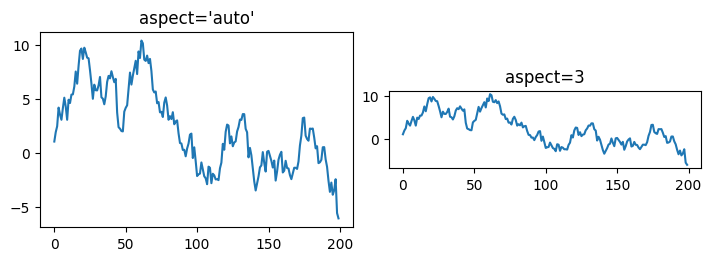

In [6]:
fig, axs = plt.subplots(ncols=2, figsize=(7, 2.5), layout="constrained")
np.random.seed(19680801)
t = np.arange(200)
x = np.cumsum(np.random.randn(200))
axs[0].plot(t, x)
axs[0].set_title("aspect='auto'")

axs[1].plot(t, x)
axs[1].set_aspect(3)
axs[1].set_title("aspect=3")

# Arranging Multiple Axes in a Figure

## Create grid-shaped combinations of Axes
<dl>
    <dt style='font-weight:bold;color:green;'>subplots</dt>
    <dd>Creates and places all Axes in the figure at once: returns an array of Axes</dd>
    <dt style='font-weight:bold;color:green;'>subplot_mosaic</dt>
    <dd>Creates and places all Axes in the figure at once: returns a Dictionary<br/>
    Axes can also span whole rows or columns.</dd>
</dl>

## Adding single Axes at a time

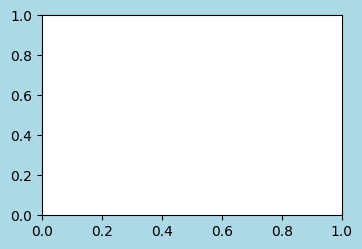

In [7]:
# The figure size is 4X3 inches
w, h = 4, 3
margin = 0.5

# First, create the figure
fig = plt.figure(figsize=(w, h), facecolor="lightblue")

# Next, add the Axes object to the figure
# Pass a list of [left, bottom, width, height] for the rectangle
# of the Axes, with values figure-normalized
ax = fig.add_axes([margin / w, margin / h, (w - 2 * margin) / w, (h - 2 * margin) / h])

## High-level methods for making grids
### Basic 2x2 grid

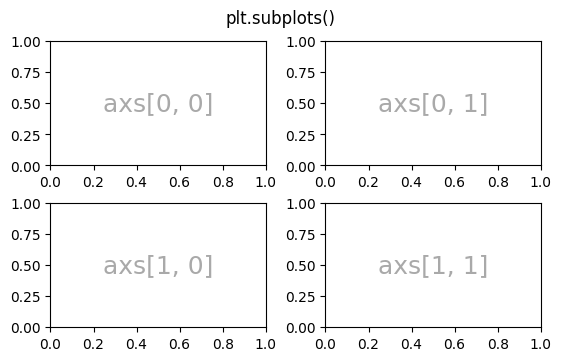

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(5.5, 3.5), layout="constrained")

# add an artist, in this case a nice label in the middle
for row in range(2):
    for col in range(2):
        axs[row, col].annotate(
            f"axs[{row}, {col}]",
            (0.5, 0.5),
            transform=axs[row, col].transAxes,
            ha="center",
            va="center",
            fontsize=18,
            color="darkgrey",
        )

fig.suptitle("plt.subplots()")
plt.show()

In [9]:
from matplotlib.axes import Axes


def annotate_axes(ax: Axes, text: str, fontsize=18, color="darkgrey"):
    """Encapsulate all annotation parameters of an Axes object."""
    ax.text(
        0.5,
        0.5,
        text,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=color,
    )

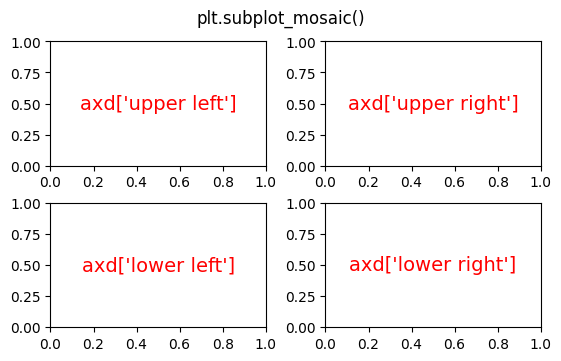

In [10]:
# Each list below represents a row with meaningbul names.
# axd is a Dictionary not an array (as in subplots())
fig, axd = plt.subplot_mosaic(
    [
        ["upper left", "upper right"],
        ["lower left", "lower right"],
    ],
    figsize=(5.5, 3.5),
    layout="constrained",
)

for k, ax in axd.items():
    annotate_axes(ax, f"axd[{k!r}]", fontsize=14, color="red")

fig.suptitle("plt.subplot_mosaic()")
plt.show()

### Grids of fixed-aspect ratio Axes

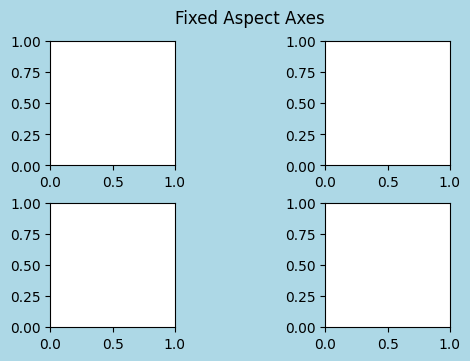

In [11]:
# Fixed-aspect axes may lead to large gaps by default:
fig, axs = plt.subplots(2, 2, figsize=(5.5, 3.5), facecolor="lightblue", layout="constrained")

# NOTE: flat is a 1-D iterator of a numpy.ndarray
for ax in axs.flat:
    # same scaling for x and y
    ax.set_aspect(1)

fig.suptitle("Fixed Aspect Axes")
plt.show()

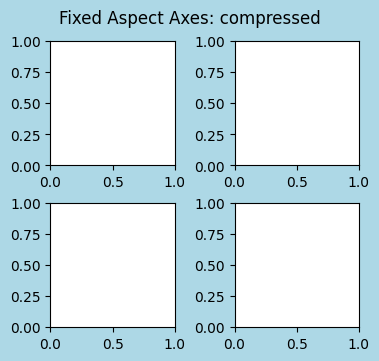

In [12]:
# To reduce the gaps between Axes when using fixed-aspect ratio, use layout="compressed"
fig, axs = plt.subplots(2, 2, figsize=(5.5, 3.5), facecolor="lightblue", layout="compressed")

# NOTE: flat is a 1-D iterator of a numpy.ndarray
for ax in axs.flat:
    # same scaling for x and y
    ax.set_aspect(1)

fig.suptitle("Fixed Aspect Axes: compressed")
plt.show()

### Axes spanning rows or columns in a grid

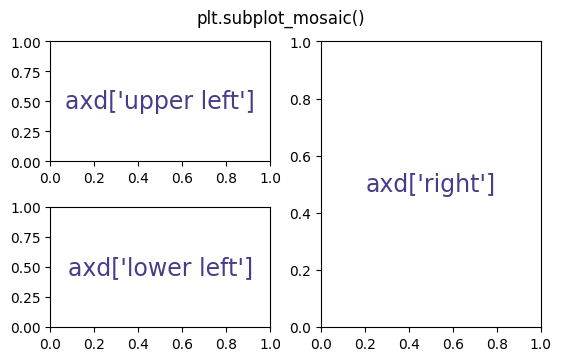

In [13]:
fig, axd = plt.subplot_mosaic(
    [
        ["upper left", "right"],
        ["lower left", "right"],
    ],
    figsize=(5.5, 3.5),
    layout="constrained",
)

for k, ax in axd.items():
    annotate_axes(ax, f"axd[{k!r}]", fontsize=17, color="darkslateblue")

fig.suptitle("plt.subplot_mosaic()")
plt.show()

### Variable widths or heights in a grid

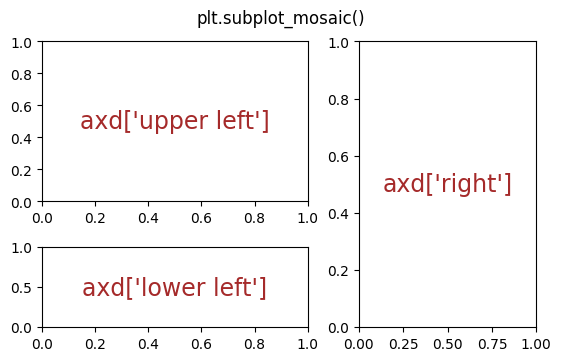

In [14]:
fig, axd = plt.subplot_mosaic(
    [
        ["upper left", "right"],
        ["lower left", "right"],
    ],
    figsize=(5.5, 3.5),
    layout="constrained",
    gridspec_kw=dict(
        width_ratios=[1.5, 1],
        height_ratios=[2, 1],
    ),
)

for k, ax in axd.items():
    annotate_axes(ax, f"axd[{k!r}]", fontsize=17, color="brown")

fig.suptitle("plt.subplot_mosaic()")
plt.show()

### Nested Axes Layout

Text(0.02, 0.5, 'ylabel for subfigs[1]')

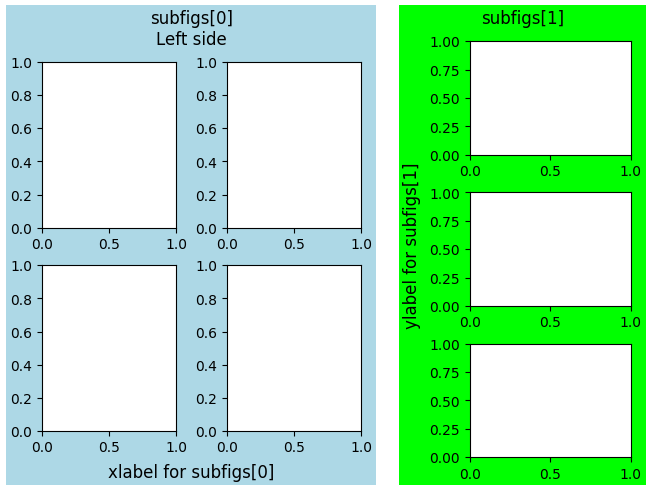

In [15]:
# Subfigure layouts independent of each other
fig = plt.figure(layout="constrained")
subfigs = fig.subfigures(1, 2, wspace=0.07, width_ratios=[1.5, 1.0])
axs0 = subfigs[0].subplots(2, 2)

subfigs[0].set_facecolor("lightblue")
subfigs[0].suptitle("subfigs[0]\nLeft side")
subfigs[0].supxlabel("xlabel for subfigs[0]")

subfigs[1].set_facecolor("lime")
axs1 = subfigs[1].subplots(3, 1)
subfigs[1].suptitle("subfigs[1]")
subfigs[1].supylabel("ylabel for subfigs[1]")

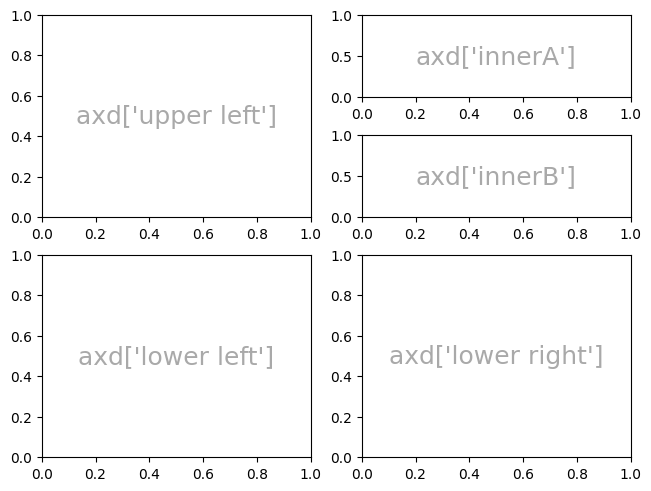

In [16]:
# Nested Axes with subplot_mosaic() using nested lists
inner = [["innerA"], ["innerB"]]
outer = [
    ["upper left", inner],
    ["lower left", "lower right"],
]

fig, axd = plt.subplot_mosaic(outer, layout="constrained")

for k, ax in axd.items():
    annotate_axes(ax, f"axd[{k!r}]")

## Low-level and advanced grid methods

### Basic 2x2 grid

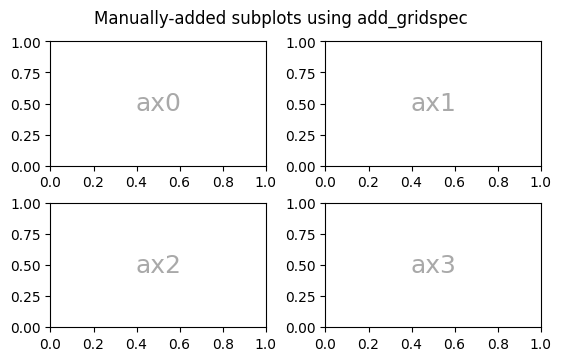

In [17]:
fig = plt.figure(figsize=(5.5, 3.5), layout="constrained")
spec = fig.add_gridspec(nrows=2, ncols=2)

ax0 = fig.add_subplot(spec[0, 0])
annotate_axes(ax0, "ax0")

ax1 = fig.add_subplot(spec[0, 1])
annotate_axes(ax1, "ax1")

ax2 = fig.add_subplot(spec[1, 0])
annotate_axes(ax2, "ax2")

ax3 = fig.add_subplot(spec[1, 1])
annotate_axes(ax3, "ax3")

fig.suptitle("Manually-added subplots using add_gridspec")
plt.show()

### Axes spanning rows or grids in a grid

Text(0.5, 0.98, 'Manually-added subplots, spanning a column')

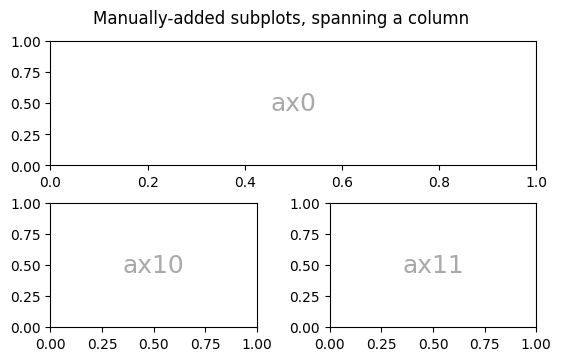

In [18]:
fig = plt.figure(figsize=(5.5, 3.5), layout="constrained")
spec = fig.add_gridspec(nrows=2, ncols=2)

ax0 = fig.add_subplot(spec[0, :])
annotate_axes(ax0, "ax0")

ax10 = fig.add_subplot(spec[1, 0])
annotate_axes(ax10, "ax10")

ax11 = fig.add_subplot(spec[1, 1])
annotate_axes(ax11, "ax11")

fig.suptitle("Manually-added subplots, spanning a column")

### Manual adjustments to a GridSpec layout

Text(0.5, 0.98, 'Manual gridspec with right=0.75')

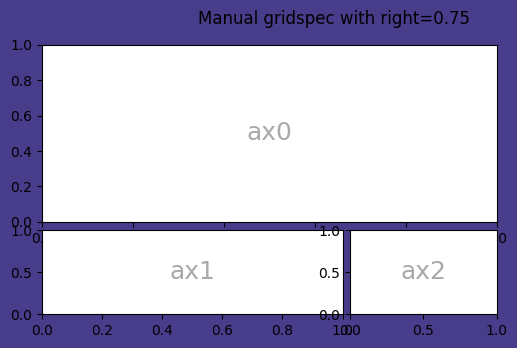

In [19]:
fig = plt.figure(figsize=(6.5, 3.5), layout=None, facecolor="darkslateblue")
gs = fig.add_gridspec(nrows=3, ncols=3, left=0.05, right=0.75, hspace=0.1, wspace=0.05)

ax0 = fig.add_subplot(gs[:-1, :])
annotate_axes(ax0, "ax0")

ax1 = fig.add_subplot(gs[-1, :-1])
annotate_axes(ax1, "ax1")

ax2 = fig.add_subplot(gs[-1, -1])
annotate_axes(ax2, "ax2")

fig.suptitle("Manual gridspec with right=0.75")

### Nested layouts with SubplotSpec

Text(0.5, 0.98, 'nested gridspecs')

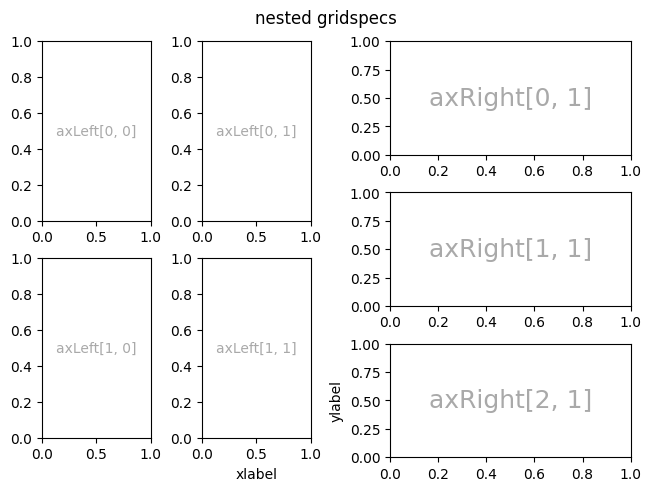

In [20]:
fig = plt.figure(layout="constrained")
gs0 = fig.add_gridspec(1, 2)

gs00 = gs0[0].subgridspec(2, 2)  # left column
gs01 = gs0[1].subgridspec(3, 1)  # right column

for a in range(2):
    for b in range(2):
        ax = fig.add_subplot(gs00[a, b])
        annotate_axes(ax, f"axLeft[{a}, {b}]", fontsize=10)
        if a == 1 and b == 1:
            ax.set_xlabel("xlabel")

for a in range(3):
    ax = fig.add_subplot(gs01[a])
    annotate_axes(ax, f"axRight[{a}, {b}]")
    if a == 2:
        ax.set_ylabel("ylabel")

fig.suptitle("nested gridspecs")

In [21]:
def squiggle_xy(a, b, c, d, i=np.arange(0.0, 2 * np.pi, 0.05)):
    return np.sin(i * a) * np.cos(i * b), np.sin(i * c) * np.cos(i * d)

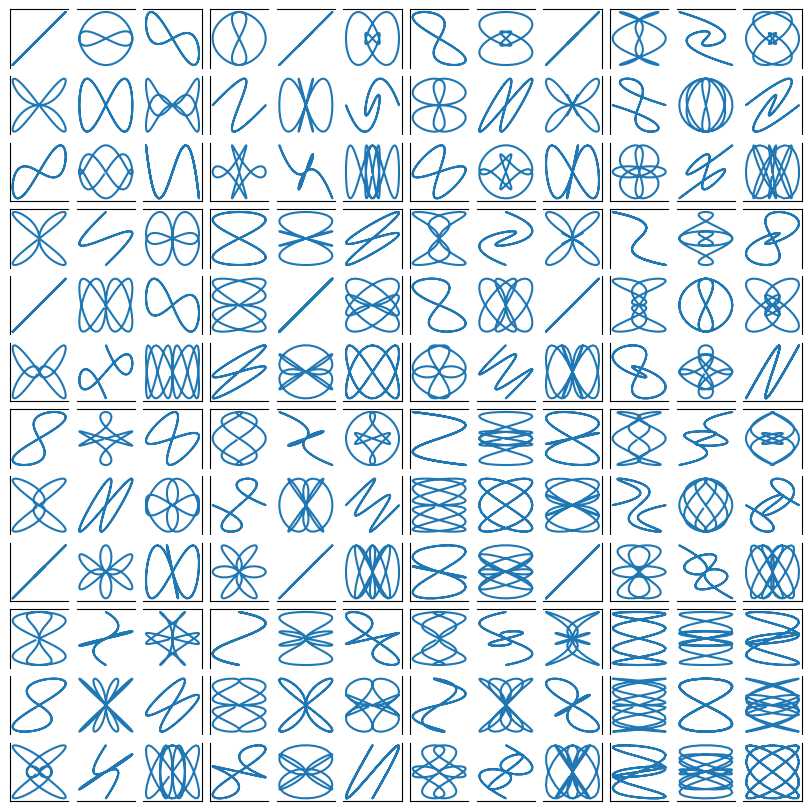

In [22]:
fig = plt.figure(figsize=(8, 8), layout="constrained")
outer_grid = fig.add_gridspec(4, 4, wspace=0, hspace=0)

for a in range(4):
    for b in range(4):
        # gridspec inside gridspec
        inner_grid = outer_grid[a, b].subgridspec(3, 3, wspace=0, hspace=0)
        # create all subplots for the inner grid
        axs = inner_grid.subplots()

        for (c, d), ax in np.ndenumerate(axs):
            ax.plot(*squiggle_xy(a + 1, b + 1, c + 1, d + 1))
            ax.set(xticks=[], yticks=[])

# show only the outside spines
for ax in fig.get_axes():
    ss = ax.get_subplotspec()
    ax.spines.top.set_visible(ss.is_first_row())
    ax.spines.bottom.set_visible(ss.is_last_row())
    ax.spines.left.set_visible(ss.is_first_col())
    ax.spines.right.set_visible(ss.is_last_col())

# Placing Colorbars

## Automatic Placement of Colorbars

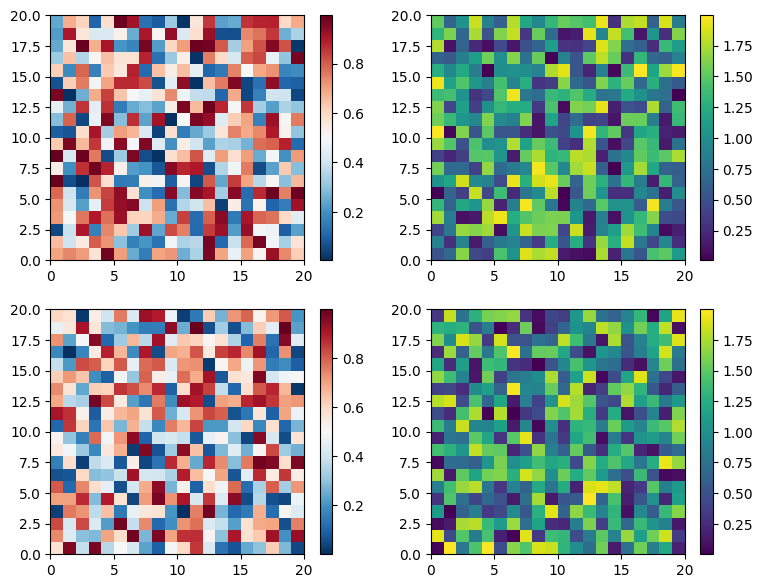

In [23]:
np.random.seed(19680801)

fig, axs = plt.subplots(2, 2, figsize=(9, 7))
cmaps = ["RdBu_r", "viridis"]

for col in range(2):
    for row in range(2):
        ax = axs[row, col]
        pcm = ax.pcolormesh(np.random.random((20, 20)) * (col + 1), cmap=cmaps[col])
        fig.colorbar(pcm, ax=ax)

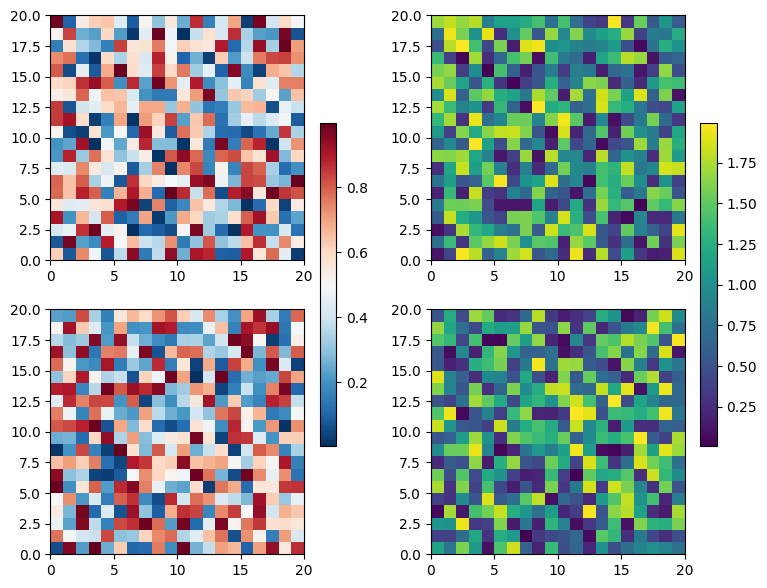

In [24]:
# To have one colorbar per column
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
cmaps = ["RdBu_r", "viridis"]

for col in range(2):
    for row in range(2):
        ax = axs[row, col]
        pcm = ax.pcolormesh(np.random.random((20, 20)) * (col + 1), cmap=cmaps[col])
    fig.colorbar(pcm, ax=axs[:, col], shrink=0.6)

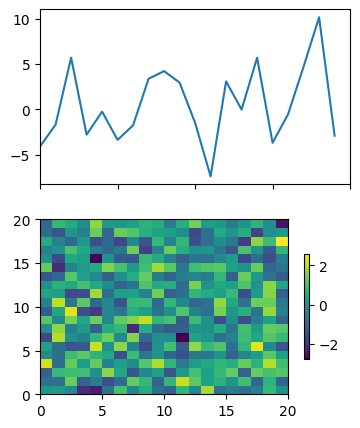

In [25]:
# Notice how the colorbar steals space and so we cannot compare the two x-axes
fig, axs = plt.subplots(2, 1, figsize=(4, 5), sharex=True)

X = np.random.randn(20, 20)
axs[0].plot(np.sum(X, axis=0))
pcm = axs[1].pcolormesh(X)

fig.colorbar(pcm, ax=axs[1], shrink=0.6)
plt.show()

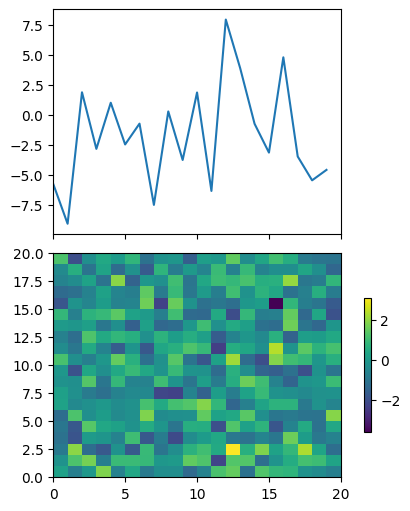

In [26]:
# To remove this undesired side effect use constrained layout
fig, axs = plt.subplots(2, 1, figsize=(4, 5), sharex=True, layout="constrained")

X = np.random.randn(20, 20)
axs[0].plot(np.sum(X, axis=0))
pcm = axs[1].pcolormesh(X)

fig.colorbar(pcm, ax=axs[1], shrink=0.6)
plt.show()

## Adjusting the spacing between colorbars and parent Axes

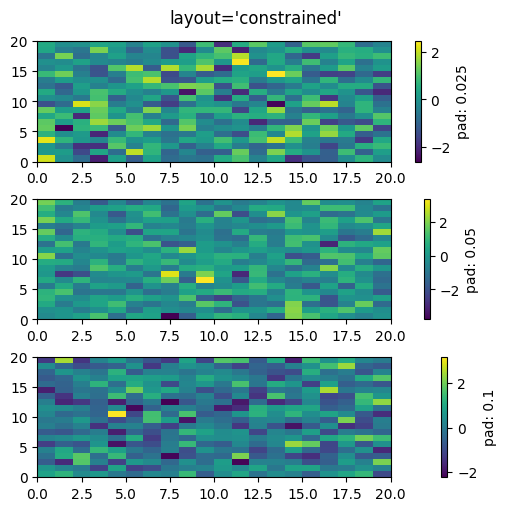

In [27]:
fig, axs = plt.subplots(3, 1, figsize=(5, 5), layout="constrained")

for ax, pad in zip(axs, [0.025, 0.05, 0.1]):
    pcm = ax.pcolormesh(np.random.randn(20, 20), cmap="viridis")
    fig.colorbar(pcm, ax=ax, pad=pad, label=f"pad: {pad}")

fig.suptitle("layout='constrained'")
plt.show()

## Manual placement of Colorbars

### Using inset_axes

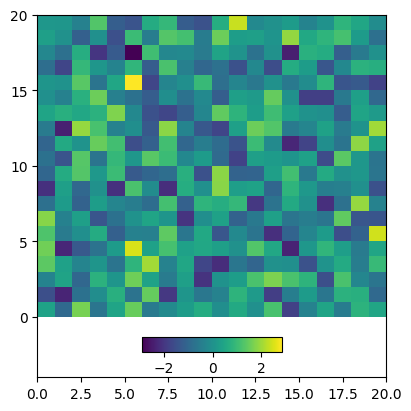

In [28]:
# Add a colorbar centered near the bottom of the parent Axes
fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")

pcm = ax.pcolormesh(np.random.randn(20, 20), cmap="viridis")
ax.set_ylim(-4, 20)
cax = ax.inset_axes([0.3, 0.07, 0.4, 0.04])
fig.colorbar(pcm, cax=cax, orientation="horizontal")

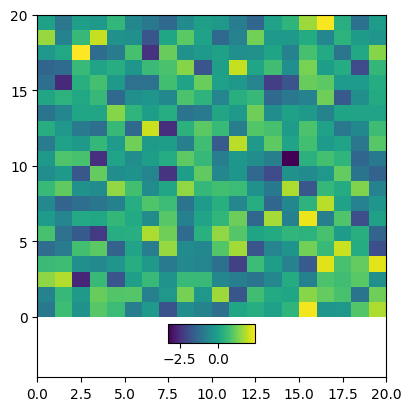

In [29]:
# Or use data coordinates
fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")

pcm = ax.pcolormesh(np.random.randn(20, 20), cmap="viridis")
ax.set_ylim(-4, 20)
cax = ax.inset_axes([7.5, -1.7, 5, 1.2], transform=ax.transData)
fig.colorbar(pcm, cax=cax, orientation="horizontal")

### Colorbars attached to fixed-aspect-ratio Axes

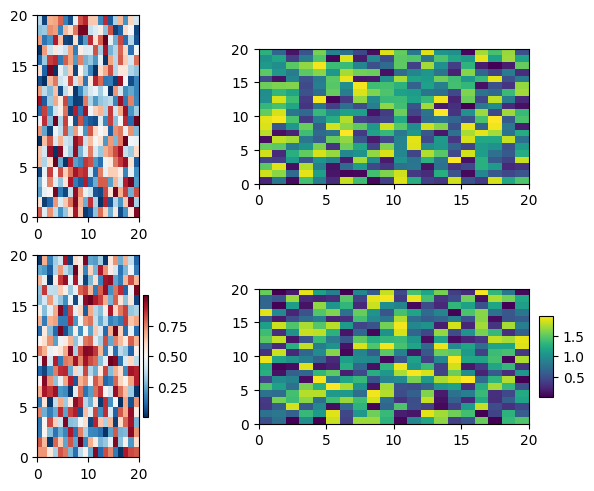

In [30]:
fig, axs = plt.subplots(2, 2, layout="constrained")
cmaps = ["RdBu_r", "viridis"]

for col in range(2):
    for row in range(2):
        ax = axs[row, col]
        pcm = ax.pcolormesh(np.random.random((20, 20)) * (col + 1), cmap=cmaps[col])

        if col == 0:
            ax.set_aspect(2)
        else:
            ax.set_aspect(1 / 2)

        if row == 1:
            cax = ax.inset_axes([1.04, 0.2, 0.05, 0.6])
            fig.colorbar(pcm, cax=cax)

# Autoscaling Axes

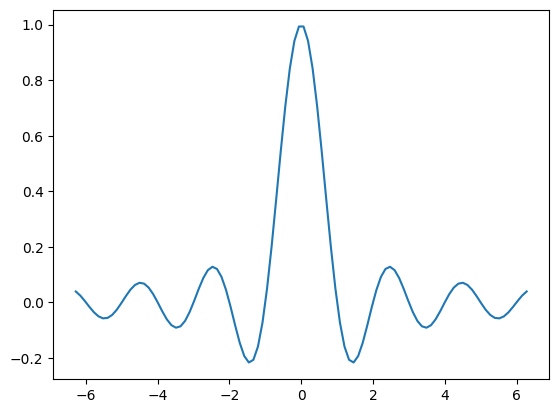

In [31]:
# Autoscaling extends the axis limits 5% beyond the data limits (-2π, 2π)
x = np.linspace(-2 * pi, 2 * pi, 100)
y = np.sinc(x)  # the normalized sinc function

fig, ax = plt.subplots()
ax.plot(x, y)

plt.show()

#### Margins

In [32]:
# The default margins around the data limits
print(ax.margins())

(0.05, 0.05)


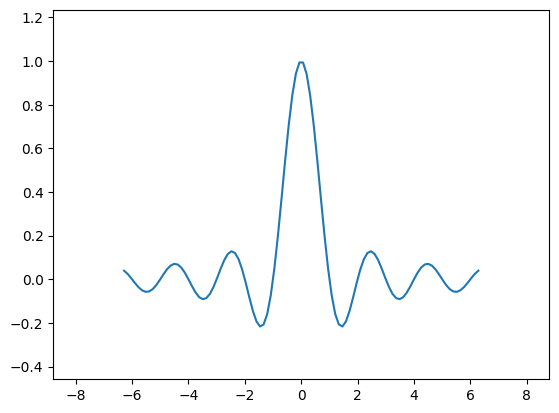

In [33]:
# We can change the default margins e.g. to 20%
fig, ax = plt.subplots()
ax.plot(x, y)
ax.margins(0.2, 0.2)

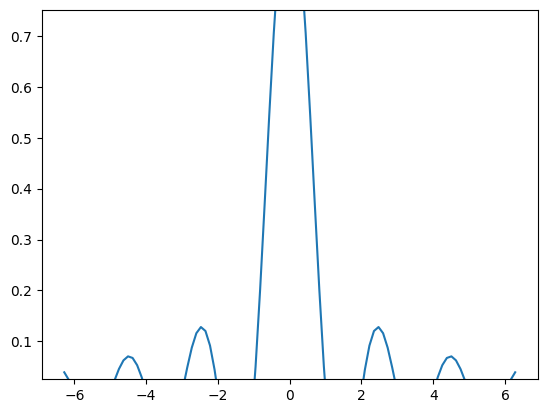

In [34]:
# Negative margins result in clipping the data
fig, ax = plt.subplots()
ax.plot(x, y)
ax.margins(y=-0.2)

#### Sticky Edges

Text(0.5, 1.0, 'margins(0.2)')

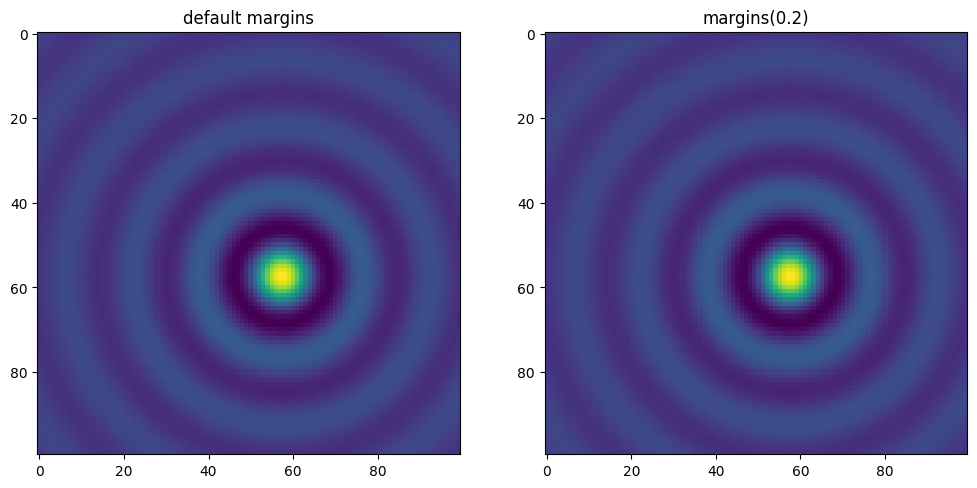

In [35]:
# There are plot elements that are used without margins
xx, yy = np.meshgrid(x, x)
zz = np.sinc(np.sqrt((xx - 1) ** 2 + (yy - 1) ** 2))

fig, ax = plt.subplots(ncols=2, figsize=(12, 8))
ax[0].imshow(zz)
ax[0].set_title("default margins")

ax[1].imshow(zz)
ax[1].margins(0.2)
ax[1].set_title("margins(0.2)")

Text(0.5, 1.0, 'default use_sticky_edges\nmargins(-0.2)')

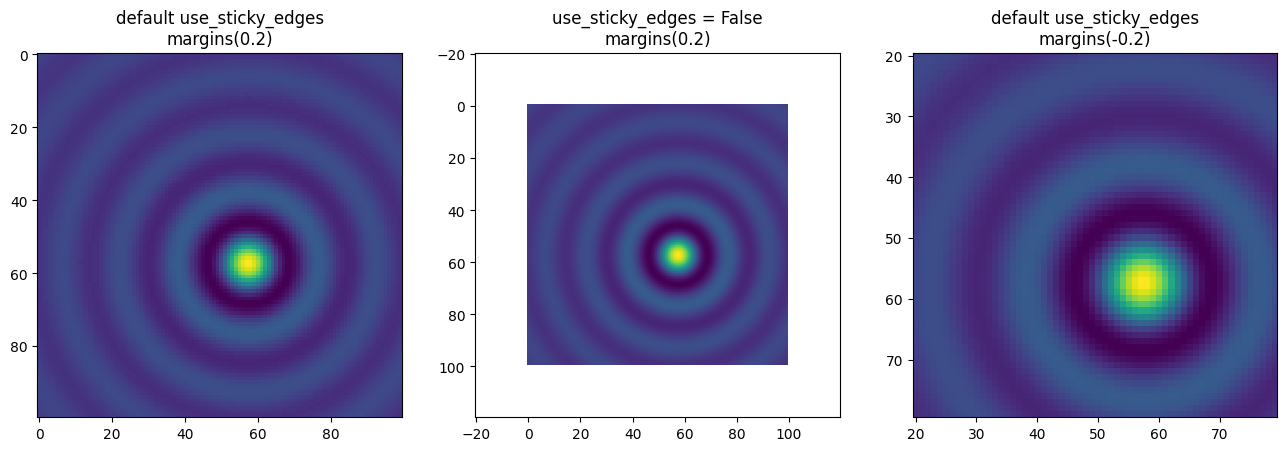

In [36]:
# Overriding sticky edges
fig, ax = plt.subplots(ncols=3, figsize=(16, 10))

ax[0].imshow(zz)
ax[0].margins(0.2)
ax[0].set_title("default use_sticky_edges\nmargins(0.2)")

ax[1].imshow(zz)
ax[1].margins(0.2)
ax[1].use_sticky_edges = False
ax[1].set_title("use_sticky_edges = False\nmargins(0.2)")

ax[2].imshow(zz)
ax[2].margins(-0.2)
ax[2].set_title("default use_sticky_edges\nmargins(-0.2)")

#### Controlling Autoscale

Text(0.5, 1.0, 'Two curves')

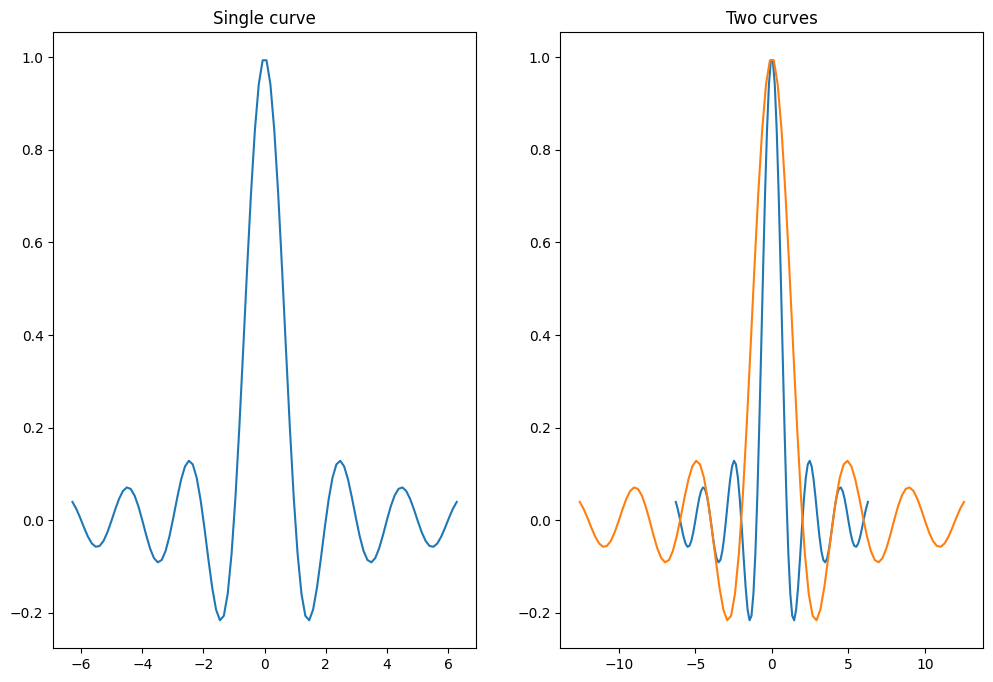

In [37]:
# The limits are recalculated when a new curve is added to the plot
fig, ax = plt.subplots(ncols=2, figsize=(12, 8))

ax[0].plot(x, y)
ax[0].set_title("Single curve")

ax[1].plot(x, y)
ax[1].plot(2 * x, y)
ax[1].set_title("Two curves")

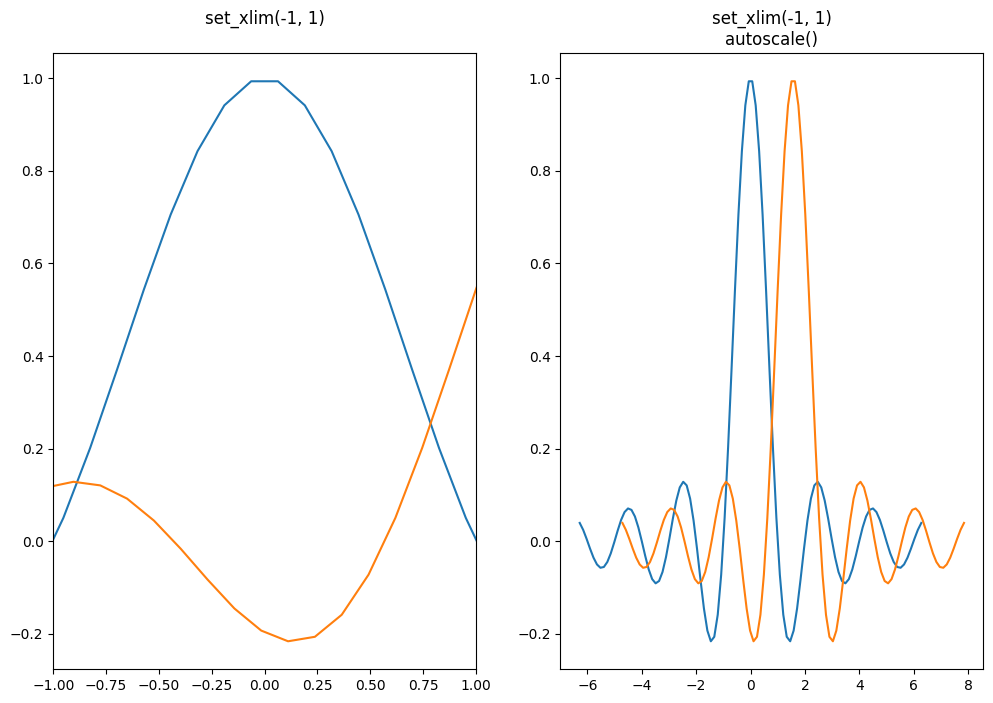

In [38]:
# To disable autoscaling set the axis limit manually
fig, ax = plt.subplots(ncols=2, figsize=(12, 8))

ax[0].plot(x, y)
ax[0].set_xlim(left=-1, right=+1)
ax[0].plot(x + pi * 0.5, y)
ax[0].set_title("set_xlim(-1, 1)\n")

ax[1].plot(x, y)
ax[1].set_xlim(left=-1, right=+1)
ax[1].plot(x + pi * 0.5, y)
ax[1].autoscale()
ax[1].set_title("set_xlim(-1, 1)\nautoscale()")

plt.show()

In [39]:
print(ax[0].get_autoscale_on())  # False means disabled
print(ax[1].get_autoscale_on())  # True means enabled -> recalculated

False
True


(0, 0)


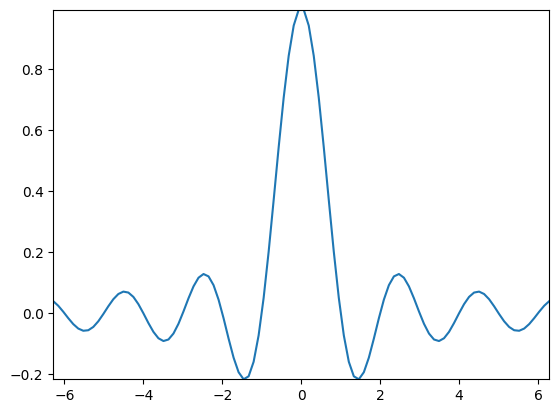

In [40]:
# Argument tight=True sets the margin to zero
fig, ax = plt.subplots()
ax.plot(x, y)
ax.margins(0.2, 0.2)
ax.autoscale(enable=None, axis="x", tight=True)

print(ax.margins())

#### Workiking with Collections

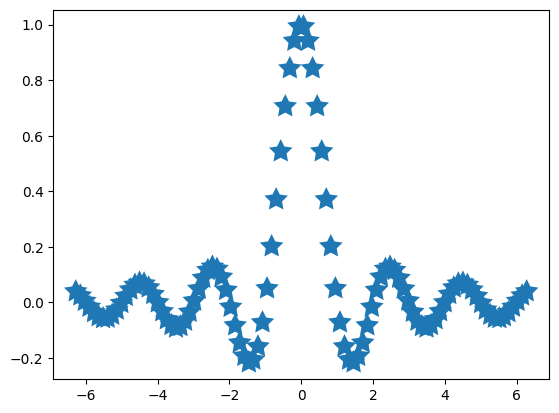

In [41]:
fig, ax = plt.subplots()
collection = mpl.collections.StarPolygonCollection(
    5,
    rotation=0,
    sizes=(250,),
    offsets=np.column_stack([x, y]),
    offset_transform=ax.transData,
)
ax.add_collection(collection)
ax.autoscale_view()

# Axis Scales

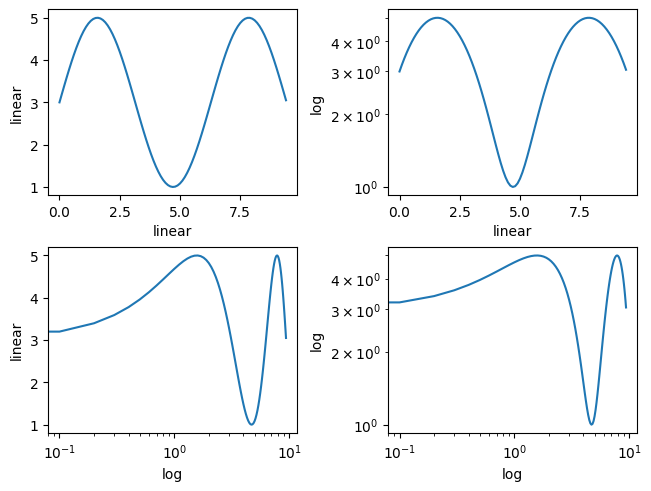

In [42]:
fig, axs = plt.subplot_mosaic(
    [
        ["linear", "linear-log"],
        ["log-linear", "log-log"],
    ],
    layout="constrained",
)

x = np.arange(0, 3 * pi, 0.1)
y = 2 * np.sin(x) + 3

ax = axs["linear"]
ax.plot(x, y)
ax.set_xlabel("linear")
ax.set_ylabel("linear")

ax = axs["linear-log"]
ax.plot(x, y)
ax.set_yscale("log")
ax.set_xlabel("linear")
ax.set_ylabel("log")

ax = axs["log-linear"]
ax.plot(x, y)
ax.set_xscale("log")
ax.set_xlabel("log")
ax.set_ylabel("linear")

ax = axs["log-log"]
ax.plot(x, y)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("log")
ax.set_ylabel("log")

plt.show()

#### loglog and semilogx/y

Text(0.5, 1.0, 'loglog(x, y)')

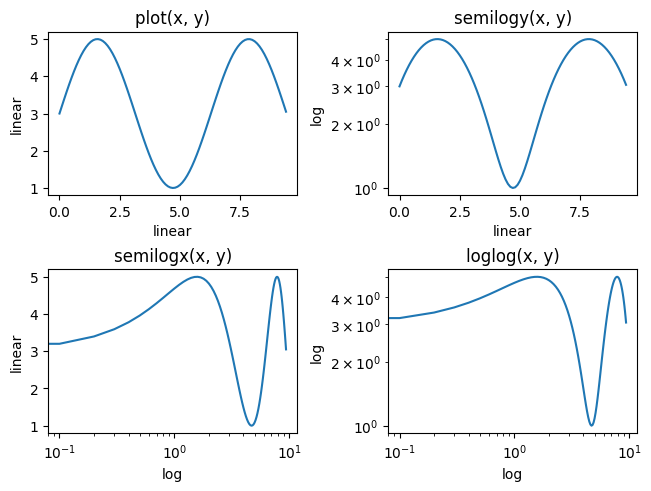

In [43]:
fig, axs = plt.subplot_mosaic(
    [
        ["linear", "linear-log"],
        ["log-linear", "log-log"],
    ],
    layout="constrained",
)

x = np.arange(0, 3 * pi, 0.1)
y = 2 * sin(x) + 3

ax = axs["linear"]
ax.plot(x, y)
ax.set_xlabel("linear")
ax.set_ylabel("linear")
ax.set_title("plot(x, y)")

ax = axs["linear-log"]
ax.semilogy(x, y)
ax.set_xlabel("linear")
ax.set_ylabel("log")
ax.set_title("semilogy(x, y)")

ax = axs["log-linear"]
ax.semilogx(x, y)
ax.set_xlabel("log")
ax.set_ylabel("linear")
ax.set_title("semilogx(x, y)")

ax = axs["log-log"]
ax.loglog(x, y)
ax.set_xlabel("log")
ax.set_ylabel("log")
ax.set_title("loglog(x, y)")

#### Other built-in Scales

In [44]:
# Here's the list of all available scales:
print(mscale.get_scale_names())

['asinh', 'function', 'functionlog', 'linear', 'log', 'logit', 'symlog']


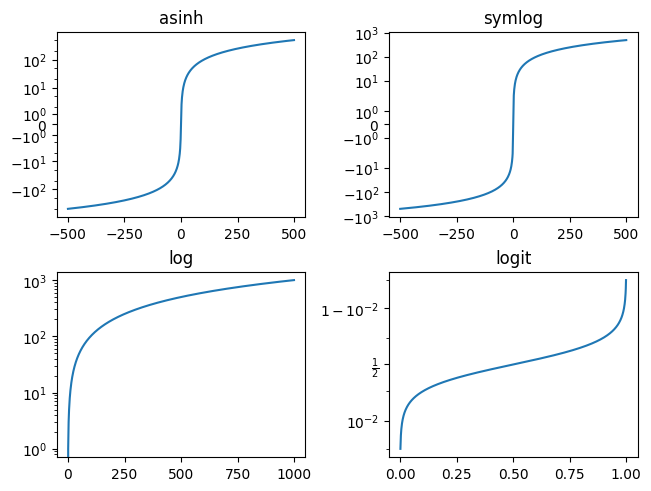

In [45]:
fig, axs = plt.subplot_mosaic(
    [
        ["asinh", "symlog"],
        ["log", "logit"],
    ],
    layout="constrained",
)

x = np.arange(0, 1000)

for name, ax in axs.items():
    if name in ["asinh", "symlog"]:
        yy = x - np.mean(x)
    elif name in ["logit"]:
        yy = x - np.min(x)
        yy = yy / np.max(np.abs(yy))
    else:
        yy = x

    ax.plot(yy, yy)
    ax.set_yscale(name)
    ax.set_title(name)

plt.show()

#### Optional Arguments for Scales

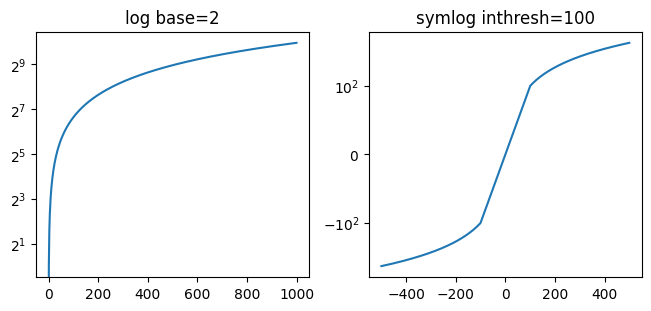

In [46]:
fig, axs = plt.subplot_mosaic(
    [["log", "symlog"]],
    layout="constrained",
    figsize=(6.4, 3),
)

for name, ax in axs.items():
    if name in ["log"]:
        ax.plot(x, x)
        ax.set_yscale("log", base=2)
        ax.set_title("log base=2")
    else:
        ax.plot(x - np.mean(x), x - np.mean(x))
        ax.set_yscale("symlog", linthresh=100)
        ax.set_title("symlog inthresh=100")

#### Arbitrary Function Scales

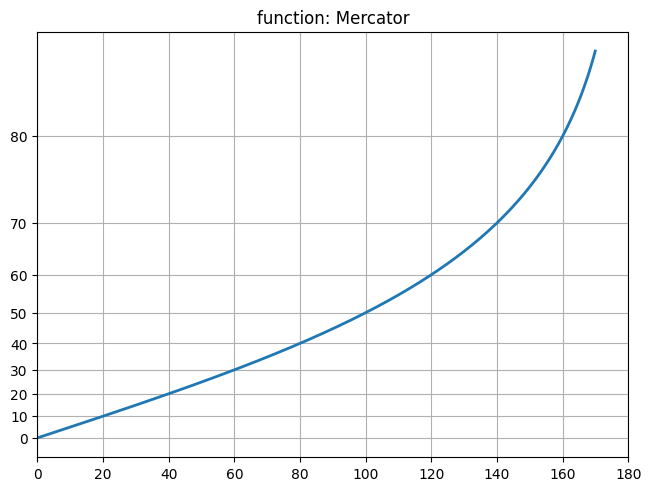

In [47]:
# A Mercator transfomr to the y-axis
def forward(a):
    a = np.deg2rad(a)
    return np.rad2deg(np.log(np.abs(np.tan(a) + 1.0 / np.cos(a))))


def inverse(a):
    a = np.deg2rad(a)
    return np.rad2deg(np.arctan(np.sinh(a)))


t = np.arange(0, 170.0, 0.1)
s = t / 2

fig, ax = plt.subplots(layout="constrained")
ax.plot(t, s, "-", lw=2)

ax.set_yscale("function", functions=(forward, inverse))
ax.set_title("function: Mercator")
ax.grid(True)
ax.set_xlim([0, 180])
ax.yaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_major_locator(FixedLocator(np.arange(0, 90, 10)))

#### What is a "scale"?

linear
log


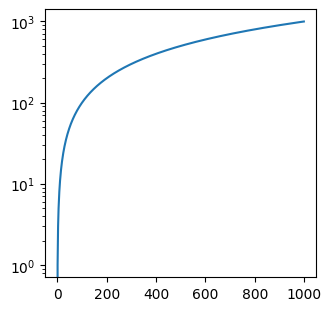

In [48]:
fig, ax = plt.subplots(figsize=(3.2, 3), layout="constrained")
ax.semilogy(x, x)

print(ax.xaxis.get_scale())
print(ax.yaxis.get_scale())

# Axis Ticks

## Manual Location and Formats

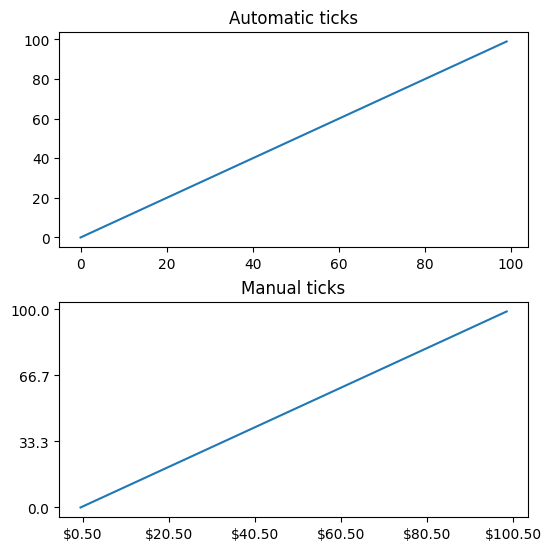

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axs = plt.subplots(2, 1, figsize=(5.4, 5.4), layout="constrained")
x = np.arange(100)

for nn, ax in enumerate(axs):
    ax.plot(x, x)

    if nn == 1:
        ax.set_title("Manual ticks")
        ax.set_yticks(np.arange(0, 100.1, 100 / 3))
        xticks = np.arange(0.5, 101, 20)
        xlabels = [f"${x:.2f}" for x in xticks]
        ax.set_xticks(xticks, labels=xlabels)
    else:
        ax.set_title("Automatic ticks")

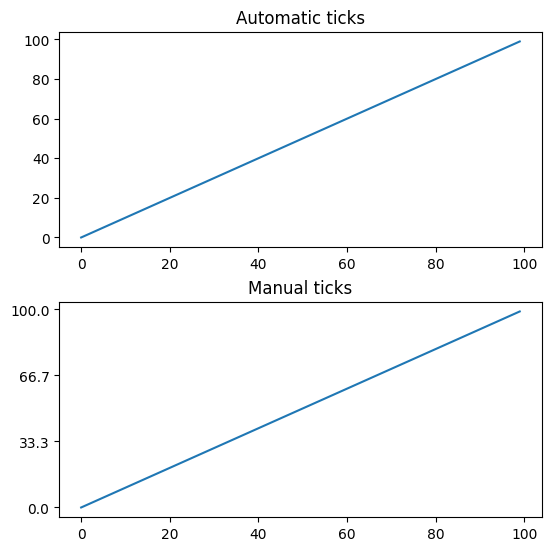

In [50]:
# We can also add minor ticks:
fig, axs = plt.subplots(2, 1, figsize=(5.4, 5.4), layout="constrained")
x = np.arange(100)

for nn, ax in enumerate(axs):
    ax.plot(x, x)

    if nn == 1:
        ax.set_title("Manual ticks")
        ax.set_yticks(np.arange(0, 100.1, 100 / 3))
        ax.set_yticks(np.arange(0, 100.1, 100 / 3), minor=True)
    else:
        ax.set_title("Automatic ticks")

## Locators and Formatters

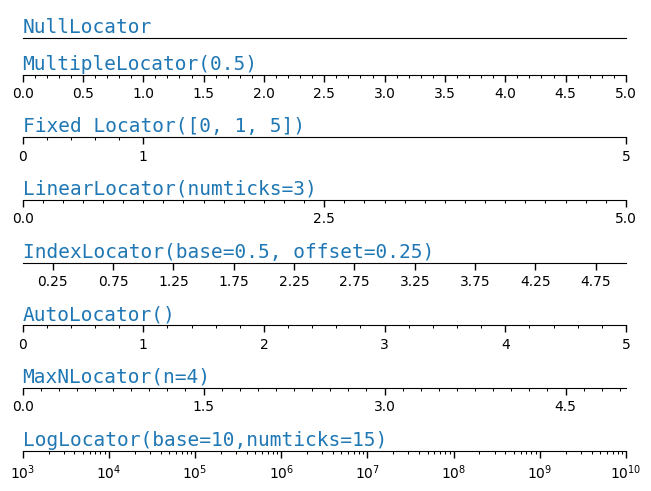

In [51]:
def setup(ax: Axes, title):
    """Set up common parameters for the Axes in the example."""

    # only show the bottom spine
    ax.yaxis.set_major_locator(ticker.NullLocator())
    ax.spines[["left", "right", "top"]].set_visible(False)

    ax.xaxis.set_ticks_position("bottom")
    ax.tick_params(which="major", width=1.00, length=5)
    ax.tick_params(which="minor", width=0.75, length=2.5)
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1)
    ax.text(0.0, 0.2, title, transform=ax.transAxes, fontsize=14, fontname="Monospace", color="tab:blue")


fig, axs = plt.subplots(8, 1, layout="constrained")

# Null Locator (no ticks)
setup(axs[0], title="NullLocator")
axs[0].xaxis.set_major_locator(ticker.NullLocator())
axs[0].xaxis.set_minor_locator(ticker.NullLocator())

# Multiple Locator(0.5) - interval between ticks is 0.5
setup(axs[1], title="MultipleLocator(0.5)")
axs[1].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axs[1].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# Fixed Locator - ticks only at a set of specific values
setup(axs[2], title="Fixed Locator([0, 1, 5])")
axs[2].xaxis.set_major_locator(ticker.FixedLocator([0, 1, 5]))
axs[2].xaxis.set_minor_locator(ticker.FixedLocator(np.linspace(0.2, 0.8, 4)))

# Linear Locator - with only 3 major ticks
setup(axs[3], title="LinearLocator(numticks=3)")
axs[3].xaxis.set_major_locator(ticker.LinearLocator(3))
axs[3].xaxis.set_minor_locator(ticker.LinearLocator(31))

# Index Locator - ticks every 0.5 points, start at 0.25
setup(axs[4], title="IndexLocator(base=0.5, offset=0.25)")
axs[4].plot(range(0, 5), [0] * 5, color="white")
axs[4].xaxis.set_major_locator(ticker.IndexLocator(base=0.5, offset=0.25))

# AutoLocator
setup(axs[5], title="AutoLocator()")
axs[5].xaxis.set_major_locator(ticker.AutoLocator())
axs[5].xaxis.set_minor_locator(ticker.AutoMinorLocator())

# MaxN Locator - max number of intervals=4
setup(axs[6], title="MaxNLocator(n=4)")
axs[6].xaxis.set_major_locator(ticker.MaxNLocator(4))
axs[6].xaxis.set_minor_locator(ticker.MaxNLocator(40))

# LogLocator
setup(axs[7], title="LogLocator(base=10,numticks=15)")
axs[7].set_xlim(10**3, 10**10)
axs[7].set_xscale("log")
axs[7].xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=25))

plt.show()

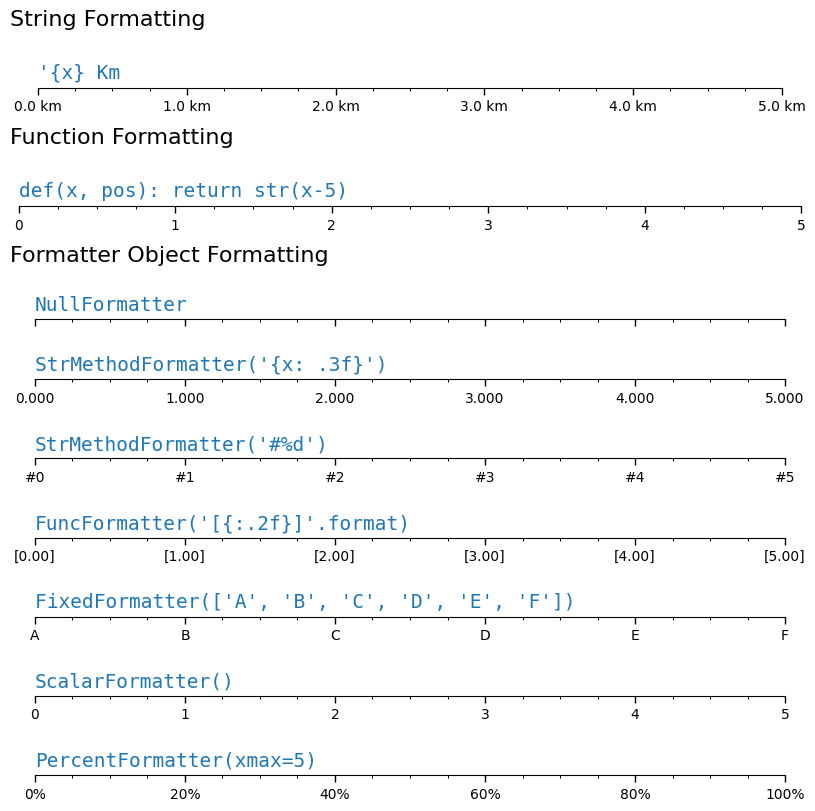

In [52]:
def setup(ax: Axes, title: str):
    """Set up common parameters for the Axes in the example."""

    # only show the bottom spine
    ax.yaxis.set_major_locator(ticker.NullLocator())  # no ticks on the y-axis
    ax.spines[["left", "right", "top"]].set_visible(False)

    # define tick positions
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.00))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

    ax.xaxis.set_ticks_position("bottom")
    ax.tick_params(which="major", width=1.00, length=5)
    ax.tick_params(which="minor", width=0.75, length=2.5, labelsize=10)
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1)
    ax.text(0.0, 0.2, title, transform=ax.transAxes, fontsize=14, fontname="Monospace", color="tab:blue")


fig = plt.figure(figsize=(8, 8), layout="constrained")
fig0, fig1, fig2 = fig.subfigures(3, height_ratios=[1.5, 1.5, 7.5])

fig0.suptitle("String Formatting", fontsize=16, x=0, ha="left")
ax0 = fig0.subplots()

setup(ax0, title="'{x} Km")
ax0.xaxis.set_major_formatter("{x} km")

fig1.suptitle("Function Formatting", fontsize=16, x=0, ha="left")
ax1 = fig1.subplots()

setup(ax1, title="def(x, pos): return str(x-5)")
ax2.xaxis.set_major_formatter(lambda x, pos: str(x - 5))

fig2.suptitle("Formatter Object Formatting", fontsize=16, x=0, ha="left")
axs2 = fig2.subplots(7, 1)

setup(axs2[0], title="NullFormatter")
axs2[0].xaxis.set_major_formatter(ticker.NullFormatter())

setup(axs2[1], title="StrMethodFormatter('{x: .3f}')")
axs2[1].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.3f}"))

setup(axs2[2], title="StrMethodFormatter('#%d')")
axs2[2].xaxis.set_major_formatter(ticker.FormatStrFormatter("#%d"))


def fmt_two_digits(x, pos):
    return f"[{x:.2f}]"


setup(axs2[3], title="FuncFormatter('[{:.2f}]'.format)")
axs2[3].xaxis.set_major_formatter(ticker.FuncFormatter(fmt_two_digits))

setup(axs2[4], title="FixedFormatter(['A', 'B', 'C', 'D', 'E', 'F'])")
# FixedFormatter should only be used together with FixedLocator.
# Otherwise, one cannot be sure where the labels will end up.
positions = [0, 1, 2, 3, 4, 5]
labels = ["A", "B", "C", "D", "E", "F"]
axs2[4].xaxis.set_major_locator(ticker.FixedLocator(positions))
axs2[4].xaxis.set_major_formatter(ticker.FixedFormatter(labels))

setup(axs2[5], title="ScalarFormatter()")
axs2[5].xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))

setup(axs2[6], title="PercentFormatter(xmax=5)")
axs2[6].xaxis.set_major_formatter(ticker.PercentFormatter(xmax=5))

## Styling Ticks (tick parameters)

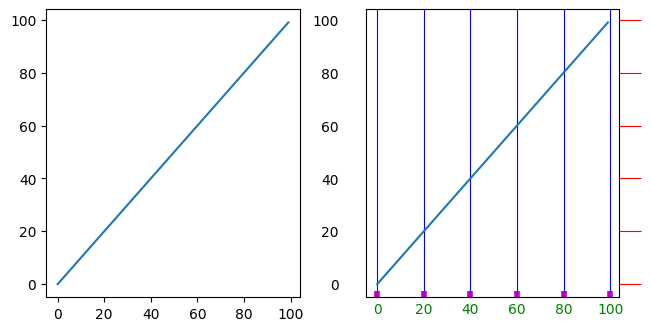

In [53]:
fig, axs = plt.subplots(1, 2, figsize=(6.4, 3.2), layout="constrained")

for nn, ax in enumerate(axs):
    ax.plot(np.arange(100))

    if nn == 1:
        ax.grid("on")
        ax.tick_params(axis="y", right=True, left=False, color="r", length=16, grid_color="none")
        ax.tick_params(axis="x", color="m", length=4, direction="in", width=4, labelcolor="g", grid_color="b")

# Plotting dates and strings
## Date Conversion

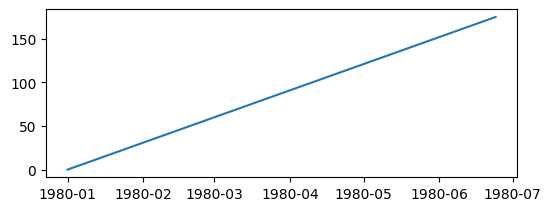

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.units as munits

fig, ax = plt.subplots(figsize=(5.4, 2), layout="constrained")

# NOTE: The converter converts from np.datetime64 to float.
#       The locator puts ticks at the beginning of each month.
#       The formatter labels the ticks appropriately.
time = np.arange("1980-01-01", "1980-06-25", dtype=np.datetime64)
x = np.arange(len(time))
ax.plot(time, x)

plt.show()

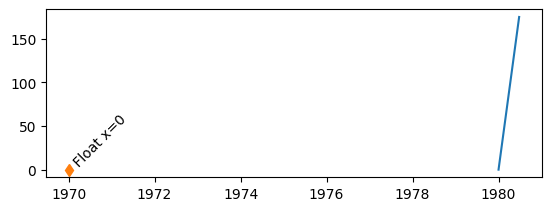

In [55]:
fig, ax = plt.subplots(figsize=(5.4, 2), layout="constrained")

time = np.arange("1980-01-01", "1980-06-25", dtype=np.datetime64)
x = np.arange(len(time))
ax.plot(time, x)
# Plotting a float on the x-axis, it will be plotted in units of days
# since the "epoch" of the converter i.e. 1970-01-01
ax.plot(0, 0, "d")
ax.text(0, 0, " Float x=0", rotation=45)

plt.show()

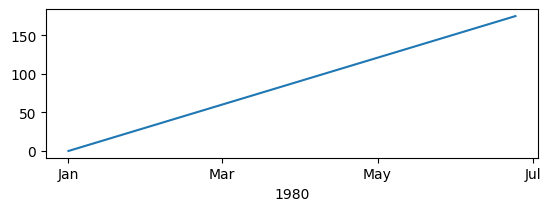

In [56]:
fig, ax = plt.subplots(figsize=(5.4, 2), layout="constrained")

time = np.arange("1980-01-01", "1980-06-25", dtype="datetime64[D]")
x = np.arange(len(time))
ax.plot(time, x)
# The Locator places the ticks by every second month.
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=np.arange(1, 13, 2)))
# The formatter uses the month's 3-letter name.
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlabel("1980")

plt.show()

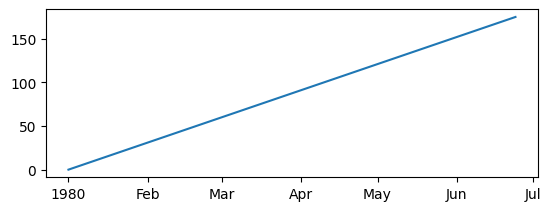

In [57]:
# The ConciseDateFormatter uses "1980" instead of Jan, at the start of the year.
plt.rcParams["date.converter"] = "concise"

fig, ax = plt.subplots(figsize=(5.4, 2), layout="constrained")

time = np.arange("1980-01-01", "1980-06-25", dtype=np.datetime64)
x = np.arange(len(time))
ax.plot(time, x)

plt.show()

(3683, 3743)

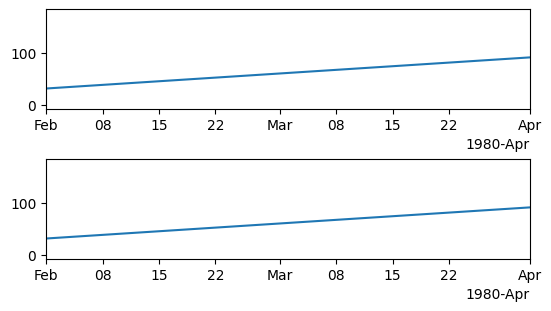

In [58]:
fig, axs = plt.subplots(2, 1, figsize=(5.4, 3), layout="constrained")

for ax in axs.flat:
    time = np.arange("1980-01-01", "1980-06-25", dtype=np.datetime64)
    x = np.arange(len(time))
    ax.plot(time, x)

# set xlim using datetime64:
axs[0].set_xlim(np.datetime64("1980-02-01"), np.datetime64("1980-04-01"))

# set xlim using floats:
axs[1].set_xlim(3683, 3683 + 60)

## String Conversion: Categorical Plots

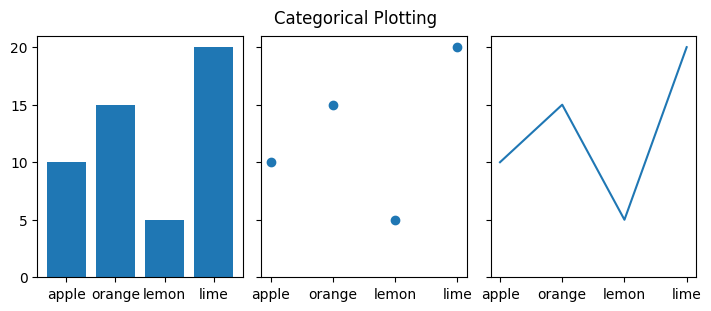

In [59]:
data = {"apple": 10, "orange": 15, "lemon": 5, "lime": 20}
names = list(data.keys())
values = list(data.values())

fig, axs = plt.subplots(1, 3, figsize=(7, 3), sharey=True, layout="constrained")
axs[0].bar(names, values)
axs[1].scatter(names, values)
axs[2].plot(names, values)
fig.suptitle("Categorical Plotting")

plt.show()

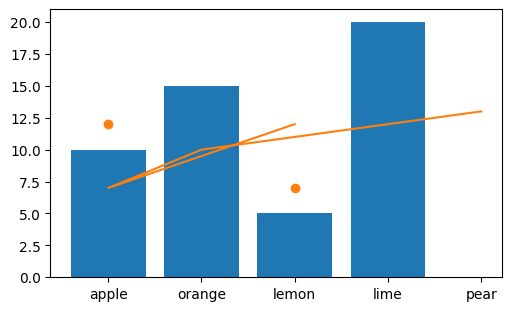

In [60]:
fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")

ax.bar(names, values)

# Plot in a different order
ax.scatter(["lemon", "apple"], [7, 12])

# Add a new category "pear" and put the other categories in a different order.
ax.plot(["pear", "orange", "apple", "lemon"], [13, 10, 7, 12], color="C1")

plt.show()

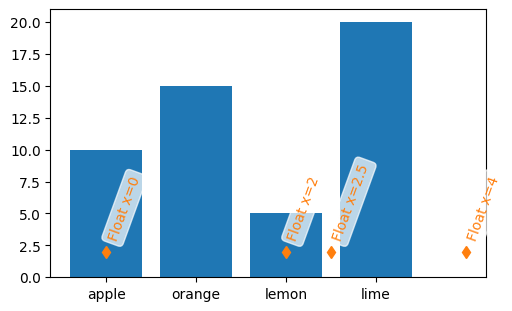

In [61]:
fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")

ax.bar(names, values)

# arguments for styling the labels below:
args = {
    "rotation": 70,
    "color": "C1",
    "bbox": {
        "color": "white",
        "alpha": 0.7,
        "boxstyle": "round",
    },
}

# 0 gets labeled as "apple"
ax.plot(0, 2, "d", color="C1")
ax.text(0, 3, "Float x=0", **args)

# 2 gets labeled as "lemon"
ax.plot(2, 2, "d", color="C1")
ax.text(2, 3, "Float x=2", **args)

# 4 doesn't get a label
ax.plot(4, 2, "d", color="C1")
ax.text(4, 3, "Float x=4", **args)

# 2.5 doesn't get a label
ax.plot(2.5, 2, "d", color="C1")
ax.text(2.5, 3, "Float x=2.5", **args)

plt.show()

Text(0.5, 0, 'limits set with floats')

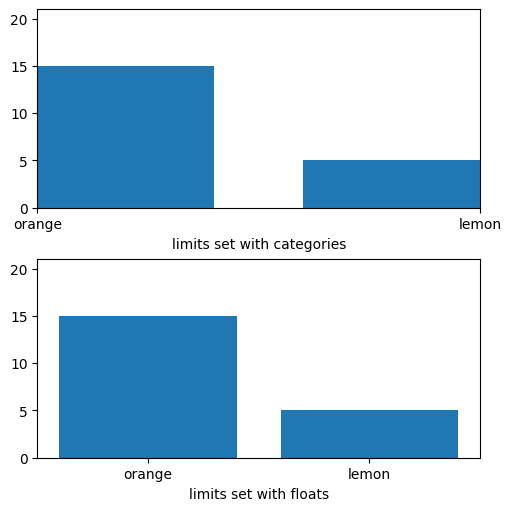

In [62]:
fig, axs = plt.subplots(2, 1, figsize=(5, 5), layout="constrained")

# Set limits for a category axis by specifying categories
ax = axs[0]
ax.bar(names, values)
ax.set_xlim("orange", "lemon")
ax.set_xlabel("limits set with categories")

# Set limits for a category axis by specifying floating point numbers
ax = axs[1]
ax.bar(names, values)
ax.set_xlim(0.5, 2.5)
ax.set_xlabel("limits set with floats")

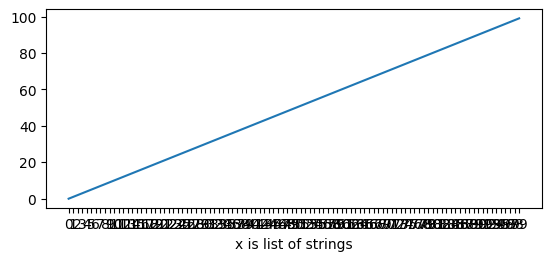

In [63]:
fig, ax = plt.subplots(figsize=(5.4, 2.5), layout="constrained")

# When data is read in as a list of strings, the categorical locator
# and formatter places ticks and labels at every string value!
x = [str(xx) for xx in np.arange(100)]
ax.plot(x, np.arange(100))
ax.set_xlabel("x is list of strings")

plt.show()

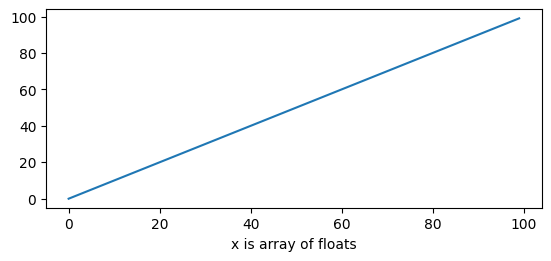

In [64]:
# To avoid the above situation, convert data to floats
fig, ax = plt.subplots(figsize=(5.4, 2.5), layout="constrained")

# Take the list of strings x, and convert to an array of floats
x = np.asarray(x, dtype="float")

ax.plot(x, np.arange(100))
ax.set_xlabel("x is array of floats")

plt.show()

## Determine converter, formatter and locator on an axis

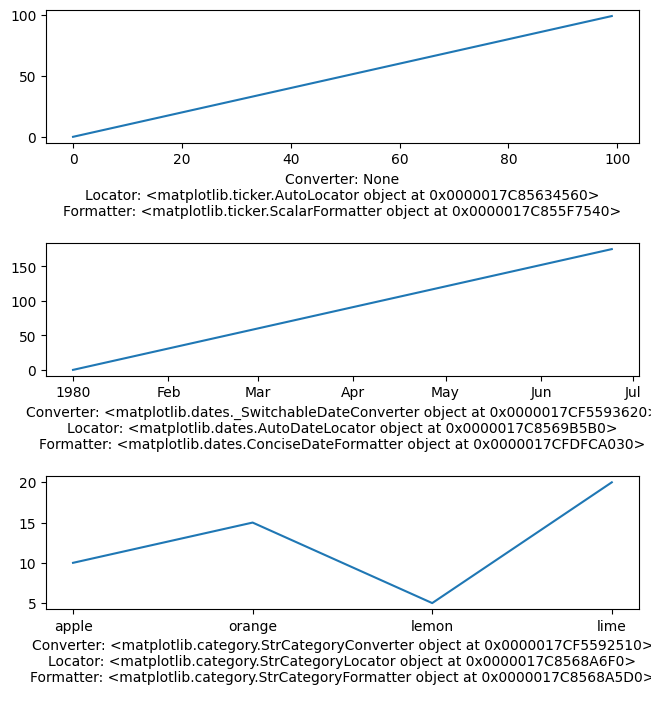

In [65]:
# To find out what matplotlib is using to convert incoming data,
# use the corresponding get_... methods:
fig, axs = plt.subplots(3, 1, figsize=(6.4, 7), layout="constrained")


def print_converter(ax):
    label = f"Converter: {ax.xaxis.get_converter()}\n"
    label += f"Locator: {ax.xaxis.get_major_locator()}\n"
    label += f"Formatter: {ax.xaxis.get_major_formatter()}\n"
    ax.set_xlabel(label)


ax = axs[0]
x = np.arange(100)
ax.plot(x, x)
print_converter(ax)

ax = axs[1]
time = np.arange("1980-01-01", "1980-06-25", dtype=np.datetime64)
x = np.arange(len(time))
ax.plot(time, x)
print_converter(ax)

ax = axs[2]
data = {"apple": 10, "orange": 15, "lemon": 5, "lime": 20}
names = list(data.keys())
values = list(data.values())
ax.plot(names, values)
print_converter(ax)

plt.show()

# Legends
## Controlling the Legend Entries

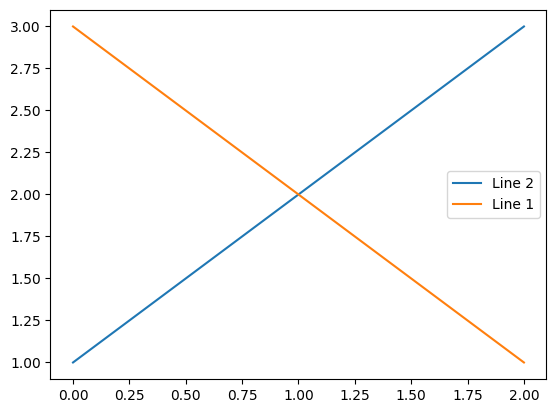

In [66]:
fig, ax = plt.subplots()
line_up = ax.plot([1, 2, 3], label="Line 2")
line_down = ax.plot([3, 2, 1], label="Line 1")

# The handles parameters is just a list of Artists
ax.legend()

## Renaming Legend Entries

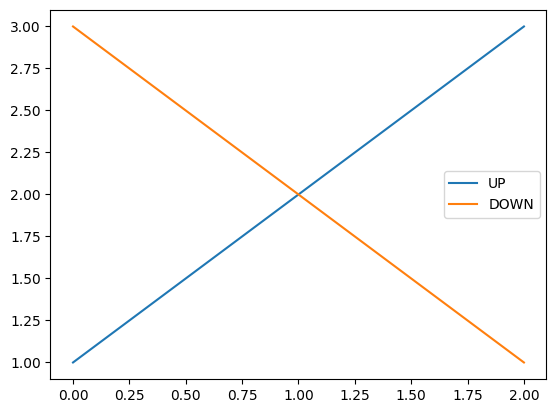

In [67]:
fig, ax = plt.subplots()
line_up = ax.plot([1, 2, 3], label="Line Up")
line_down = ax.plot([3, 2, 1], label="Line Down")

my_map = {"Line Up": "UP", "Line Down": "DOWN"}
handles, labels = ax.get_legend_handles_labels()
# The handles parameters is just a list of Artists
ax.legend(handles, [my_map[l] for l in labels])

## Creating Artists specifically for Adding to the Legend(aka Proxy Artists)

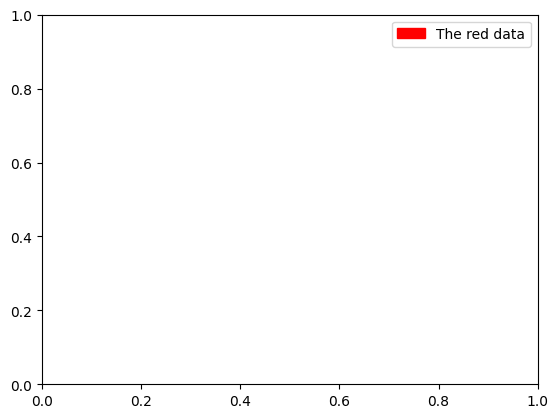

In [68]:
# A legend with an entry for some data (red color)
import matplotlib.patches as mpatches

fig, ax = plt.subplots()
red_patch = mpatches.Patch(color="red", label="The red data")
ax.legend(handles=[red_patch])

plt.show()

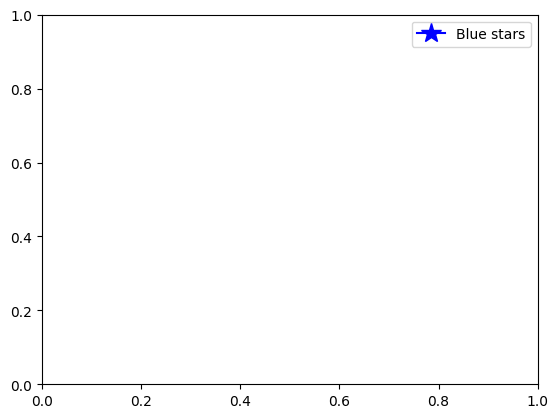

In [69]:
# A legend with a line with a marker
import matplotlib.lines as mlines

fig, ax = plt.subplots()
blue_line = mlines.Line2D([], [], color="blue", marker="*", markersize=15, label="Blue stars")
ax.legend(handles=[blue_line])

plt.show()

## Legend Location

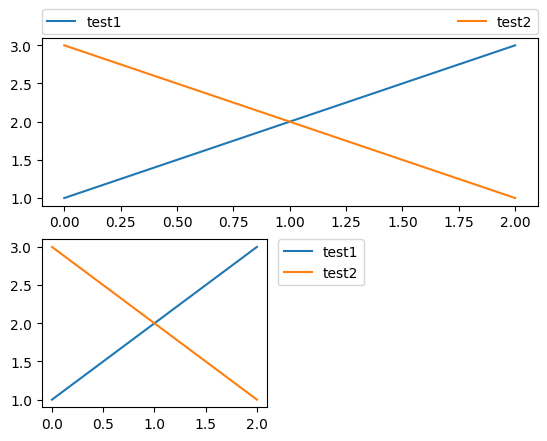

In [70]:
fig, ax_dict = plt.subplot_mosaic(
    [
        ["top", "top"],
        ["bottom", "BLANK"],
    ],
    empty_sentinel="BLANK",  # Leave the "BLANK" tile empty
)

ax_dict["top"].plot([1, 2, 3], label="test1")
ax_dict["top"].plot([3, 2, 1], label="test2")
# Place a legend above this subplot, expanding itself to
# fully use the given bounding box.
ax_dict["top"].legend(
    bbox_to_anchor=(0, 1.02, 1, 0.102),
    bbox_transform=ax_dict["top"].transAxes,
    loc="lower left",
    ncols=2,
    mode="expand",
    borderaxespad=0,
)

ax_dict["bottom"].plot([1, 2, 3], label="test1")
ax_dict["bottom"].plot([3, 2, 1], label="test2")
# Place a legend to the right of this smaller subplot.
ax_dict["bottom"].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.show()

## Figure Legends

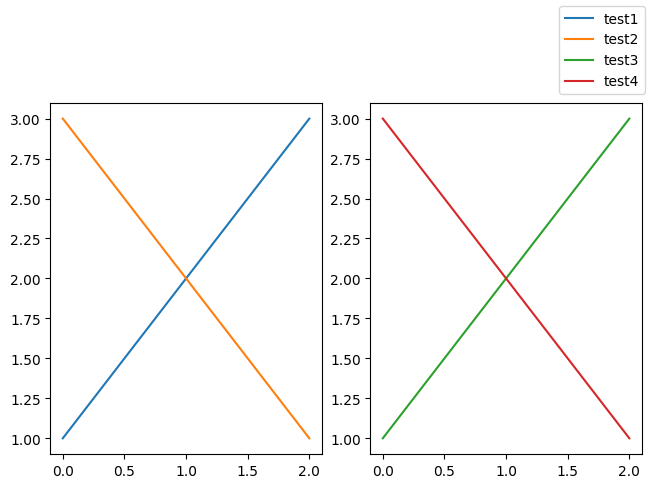

In [71]:
# How to draw the legend outside the Axes, on the figure window
fig, axs = plt.subplot_mosaic([["left", "right"]], layout="constrained")

axs["left"].plot([1, 2, 3], label="test1")
axs["left"].plot([3, 2, 1], label="test2")

axs["right"].plot([1, 2, 3], "C2", label="test3")
axs["right"].plot([3, 2, 1], "C3", label="test4")

# Place a legend to the right of this smaller subplot
fig.legend(loc="outside upper right")
plt.show()

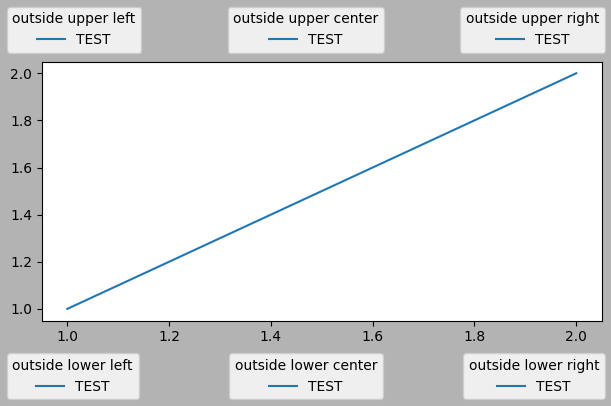

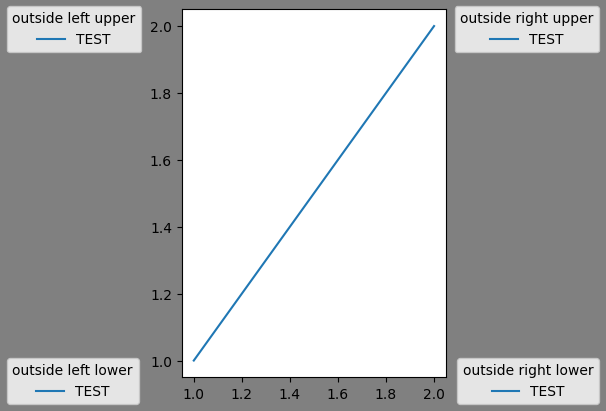

In [72]:
ucl = ["upper", "center", "lower"]
lcr = ["left", "center", "right"]

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained", facecolor="0.7")
ax.plot([1, 2], [1, 2], label="TEST")

for loc in [
    "outside upper left",
    "outside upper center",
    "outside upper right",
    "outside lower left",
    "outside lower center",
    "outside lower right",
]:
    fig.legend(loc=loc, title=loc)

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained", facecolor="0.5")
ax.plot([1, 2], [1, 2], label="TEST")

for loc in [
    "outside left upper",
    "outside right upper",
    "outside left lower",
    "outside right lower",
]:
    fig.legend(loc=loc, title=loc)

## Multiple Legends on the Same Axes

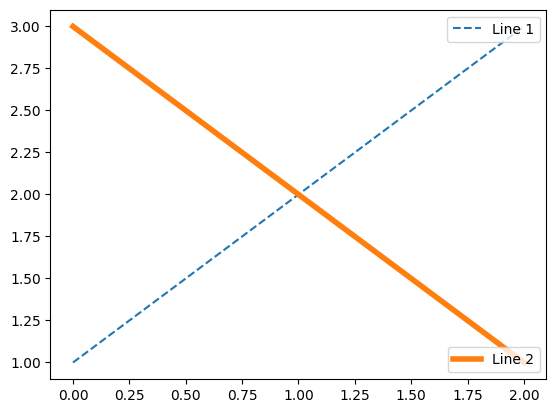

In [73]:
fig, ax = plt.subplots()
(line1,) = ax.plot([1, 2, 3], label="Line 1", linestyle="--")
(line2,) = ax.plot([3, 2, 1], label="Line 2", linewidth=4)

# Create a legend for the first line
first_legend = ax.legend(handles=[line1], loc="upper right")

# Add the legend manually to the Axes. If we don't add it
# only the last legend will appear!
ax.add_artist(first_legend)

# Create another legend for the second line
ax.legend(handles=[line2], loc="lower right")

plt.show()

## Legend Handlers

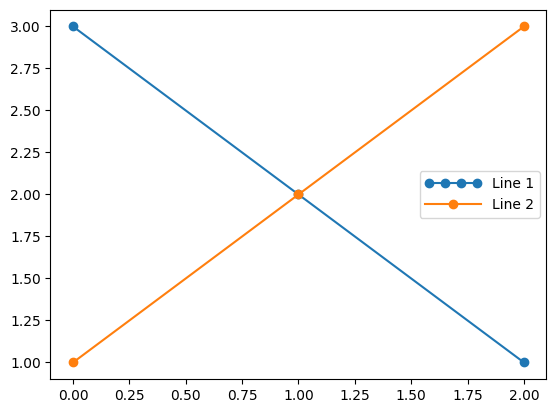

In [74]:
from matplotlib.legend_handler import HandlerLine2D

fig, ax = plt.subplots()
(line1,) = ax.plot([3, 2, 1], marker="o", label="Line 1")
(line2,) = ax.plot([1, 2, 3], marker="o", label="Line 2")

ax.legend(handler_map={line1: HandlerLine2D(numpoints=4)}, handlelength=4)

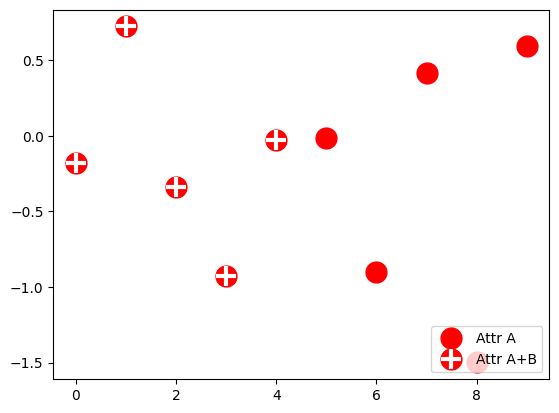

In [75]:
from numpy.random import randn

z = randn(10)

fig, ax = plt.subplots()
(red_dot,) = ax.plot(z, "ro", markersize=15)

# Put a white cross over some of the data
(white_cross,) = ax.plot(z[:5], "w+", markeredgewidth=3, markersize=15)

ax.legend([red_dot, (red_dot, white_cross)], ["Attr A", "Attr A+B"], loc="lower right")

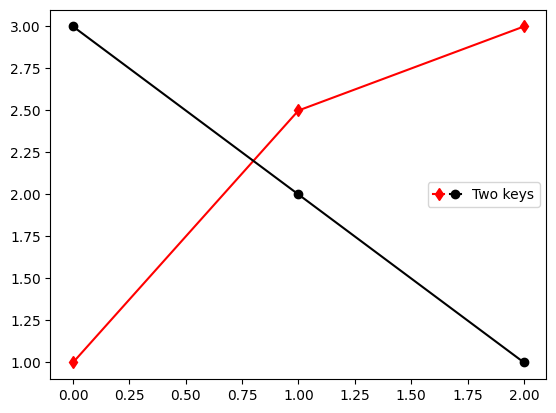

In [76]:
# Assigning two legend keys to the same entry
from matplotlib.legend_handler import HandlerLine2D, HandlerTuple

fig, ax = plt.subplots()
(p1,) = ax.plot([1, 2.5, 3], "r-d")
(p2,) = ax.plot([3, 2, 1], "k-o")

l = ax.legend(
    [(p1, p2)],
    ["Two keys"],
    numpoints=1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)

## Implementing a Custom Legend Handler

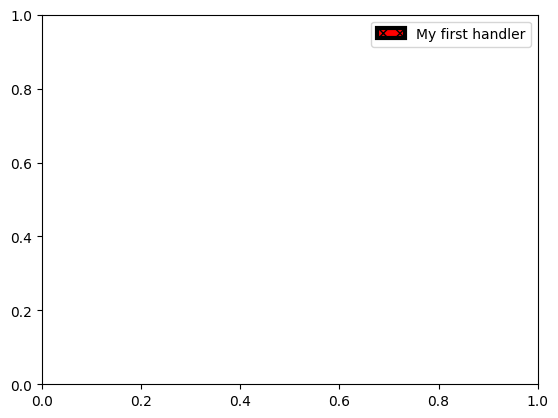

In [77]:
import matplotlib.patches as mpatches


class AnyObject:
    pass


class AnyObjectHandler:
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width, height = handlebox.width, handlebox.height
        patch = mpatches.Rectangle(
            [x0, y0],
            width,
            height,
            facecolor="red",
            edgecolor="black",
            hatch="xx",
            lw=3,
            transform=handlebox.get_transform(),
        )
        handlebox.add_artist(patch)
        return patch


fig, ax = plt.subplots()
ax.legend([AnyObject()], ["My first handler"], handler_map={AnyObject: AnyObjectHandler()})

# Subplot mosaic

In [78]:
import matplotlib.pyplot as plt
import numpy as np


# Helper function used for visualization in the following examples
def identify_axes(ax_dict, fontsize=48):
    """
    Helper to identify the Axes in the examples below.

    Draws the label in a large font in the center of the Axes.

    Parameters
    ----------
    ax_dict: dict[str,Axes]
        Mapping between the title/label and the Axes.
    fontsize: int, optional
        How big the label should be.
    """
    kw = dict(ha="center", va="center", fontsize=fontsize, color="darkgrey")

    for k, ax in ax_dict.items():
        ax.text(0.5, 0.5, k, transform=ax.transAxes, **kw)

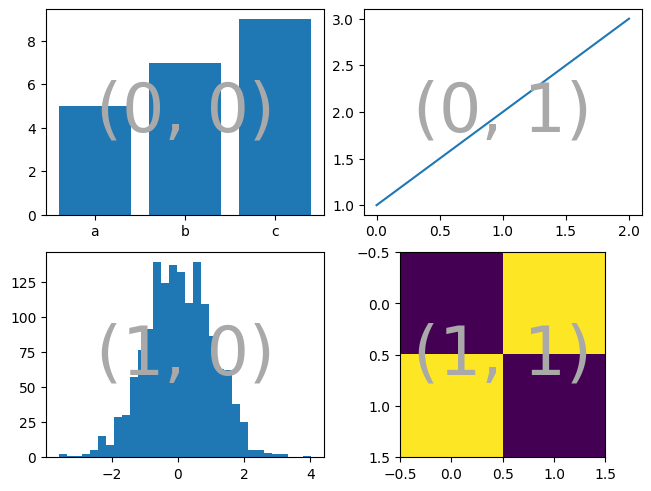

In [79]:
np.random.seed(19680801)
hist_data = np.random.randn(1500)

fig = plt.figure(layout="constrained")
ax_array = fig.subplots(2, 2, squeeze=False)

ax_array[0, 0].bar(["a", "b", "c"], [5, 7, 9])
ax_array[0, 1].plot([1, 2, 3])
ax_array[1, 0].hist(hist_data, bins="auto")
ax_array[1, 1].imshow([[1, 2], [2, 1]])

identify_axes({(j, k): a for j, r in enumerate(ax_array) for k, a in enumerate(r)})

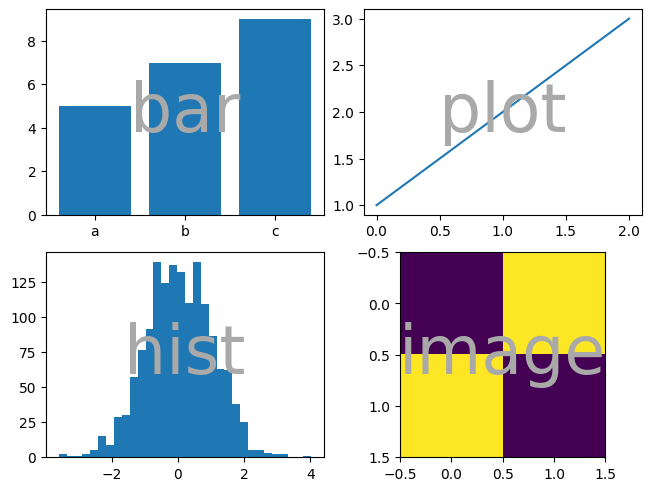

In [80]:
fig = plt.figure(layout="constrained")
ax_dict = fig.subplot_mosaic(
    [
        ["bar", "plot"],
        ["hist", "image"],
    ]
)
ax_dict["bar"].bar(["a", "b", "c"], [5, 7, 9])
ax_dict["plot"].plot([1, 2, 3])
ax_dict["hist"].hist(hist_data, bins="auto")
ax_dict["image"].imshow([[1, 2], [2, 1]])

identify_axes(ax_dict)

## String Shorthand

In [81]:
mosaic = """
AB
CD
"""

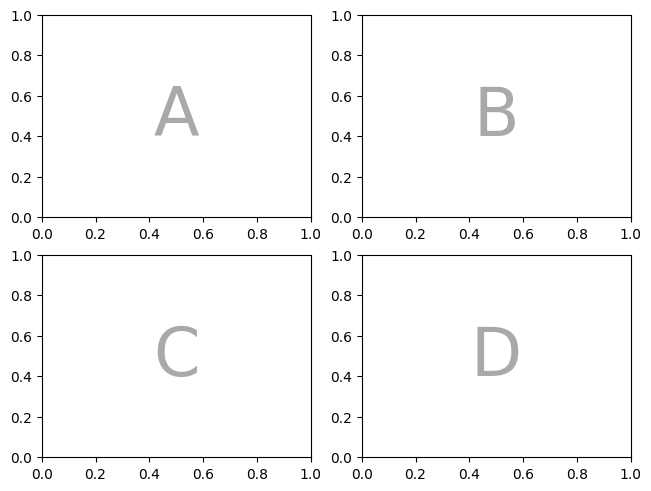

In [82]:
fig = plt.figure(layout="constrained")
ax_dict = fig.subplot_mosaic(mosaic)
identify_axes(ax_dict)

## Axes Spanning Multiple Rows/Columns

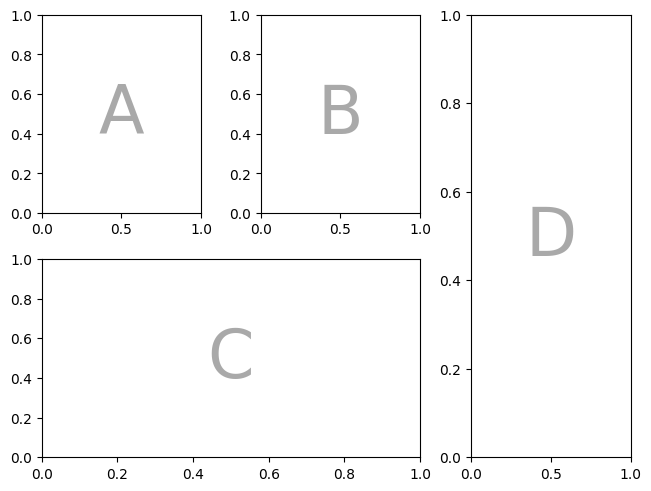

In [83]:
axd = plt.figure(layout="constrained").subplot_mosaic(
    """
    ABD
    CCD
    """
)
identify_axes(axd)

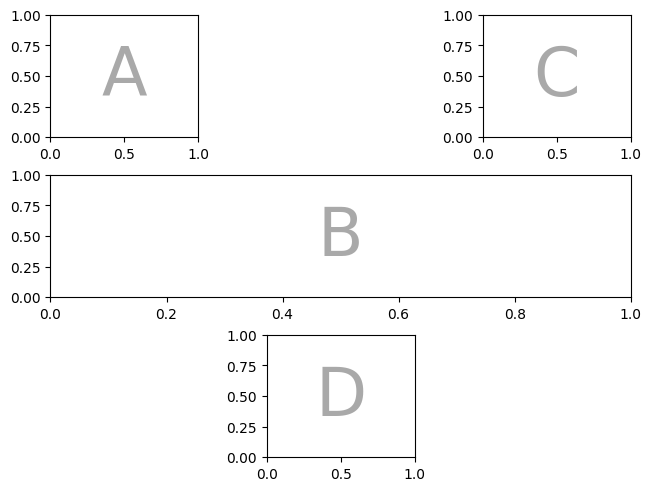

In [84]:
# Specify blank spots in the grid using a period
axd = plt.figure(layout="constrained").subplot_mosaic(
    [
        ["A", ".", "C"],
        ["B", "B", "B"],
        [".", "D", "."],
    ],
)
identify_axes(axd)

## Controlling Mosaic Creation

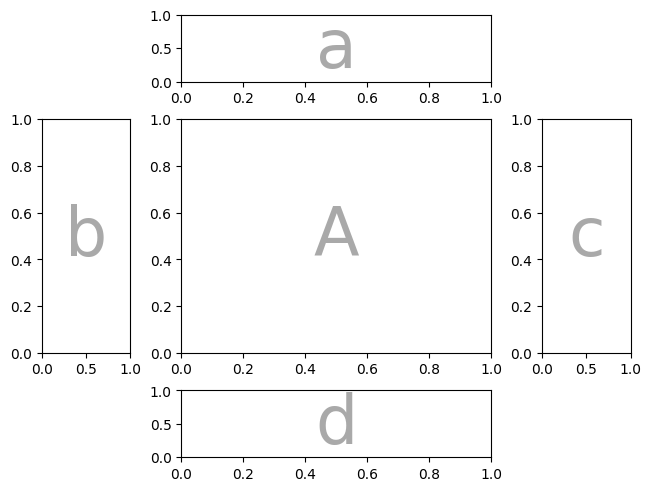

In [85]:
axd = plt.figure(layout="constrained").subplot_mosaic(
    """
    .a.
    bAc
    .d.
    """,
    height_ratios=[1, 3.5, 1],
    width_ratios=[1, 3.5, 1],
)
identify_axes(axd)

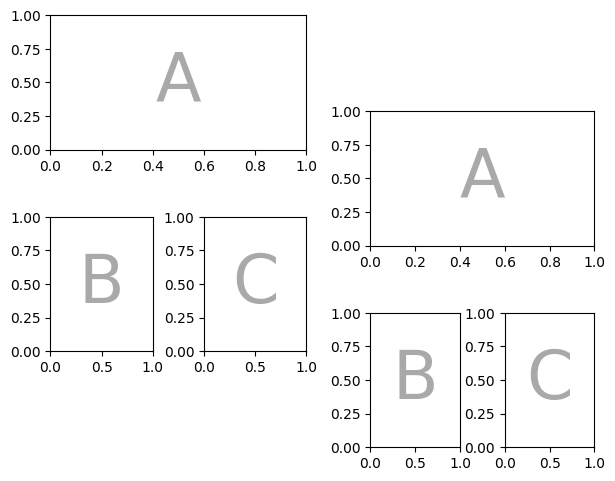

In [86]:
mosaic = """AA;BC"""
fig = plt.figure()
axd = fig.subplot_mosaic(
    mosaic,
    gridspec_kw={
        "bottom": 0.25,
        "top": 0.95,
        "left": 0.1,
        "right": 0.5,
        "wspace": 0.5,
        "hspace": 0.5,
    },
)
identify_axes(axd)

axd = fig.subplot_mosaic(
    mosaic,
    gridspec_kw={
        "bottom": 0.05,
        "top": 0.75,
        "left": 0.6,
        "right": 0.95,
        "wspace": 0.5,
        "hspace": 0.5,
    },
)
identify_axes(axd)

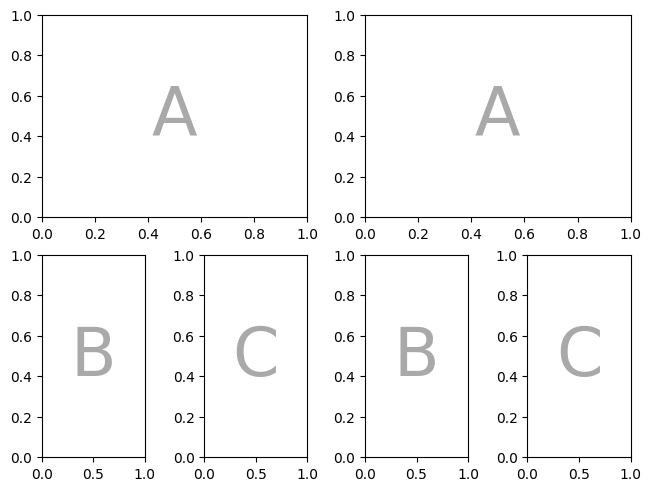

In [87]:
mosaic = """AA;BC"""
fig = plt.figure(layout="constrained")
left, right = fig.subfigures(nrows=1, ncols=2)
axd = left.subplot_mosaic(mosaic)
identify_axes(axd)

axd = right.subplot_mosaic(mosaic)
identify_axes(axd)

## Controlling Subplot Creation

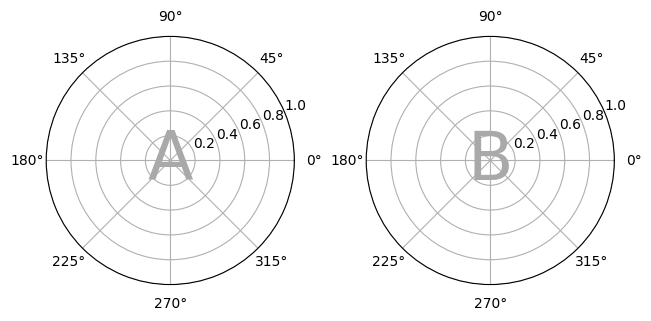

In [88]:
axd = plt.figure(layout="constrained").subplot_mosaic(
    "AB",
    subplot_kw={"projection": "polar"},
)
identify_axes(axd)

## Per-Axes Subplot Keyword Creation

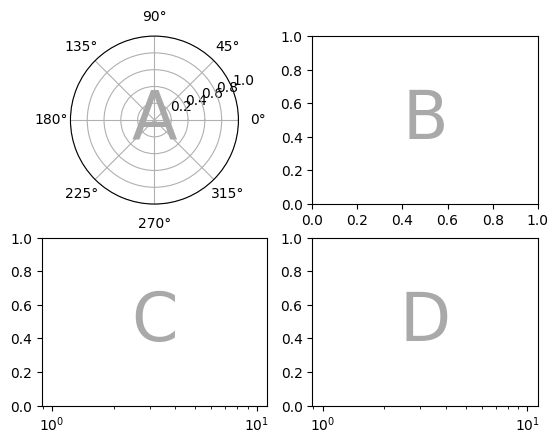

In [89]:
fig, axd = plt.subplot_mosaic(
    "AB;CD",
    per_subplot_kw={
        "A": {"projection": "polar"},
        ("C", "D"): {"xscale": "log"},
    },
)
identify_axes(axd)

## Nested List Input

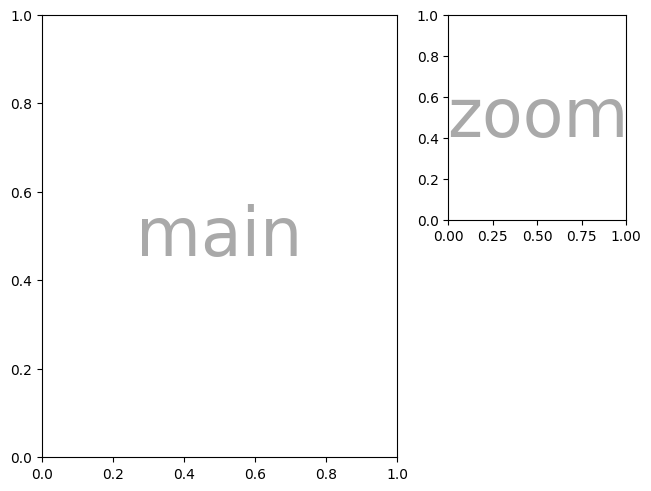

In [90]:
axd = plt.figure(layout="constrained").subplot_mosaic(
    [
        ["main", "zoom"],
        ["main", "BLANK"],
    ],
    empty_sentinel="BLANK",
    width_ratios=[2, 1],
)
identify_axes(axd)

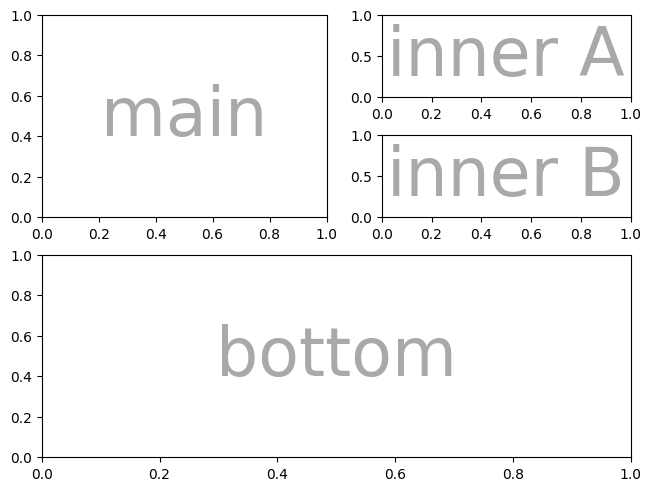

In [91]:
inner = [[]]
outer_nested_mosaic = [
    ["main", "inner"],
    ["bottom", "bottom"],
]
axd = plt.figure(layout="constrained").subplot_mosaic(
    [
        [
            "main",
            [
                ["inner A"],
                ["inner B"],
            ],
        ],
        ["bottom", "bottom"],
    ]
)
identify_axes(axd)

# Constrained Layout Guide

Adjusts subplots so that tick labels, legends and colorbars do not overlap at the same time preserving the logical layout requested by the user.

## Simple Example

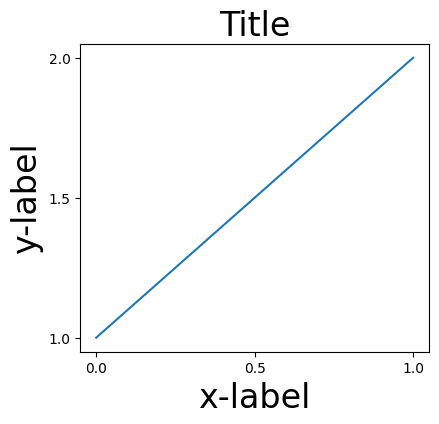

In [92]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

from matplotlib.axes import Axes

plt.rcParams["savefig.facecolor"] = "0.8"
plt.rcParams["figure.figsize"] = (4.5, 4.0)
plt.rcParams["figure.max_open_warning"] = 50


def example_plot(ax: Axes, fontsize=12, hide_labels=False):
    ax.plot([1, 2])
    ax.locator_params(nbins=3)

    if hide_labels:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    else:
        ax.set_xlabel("x-label", fontsize=fontsize)
        ax.set_ylabel("y-label", fontsize=fontsize)
        ax.set_title("Title", fontsize=fontsize)


fig, ax = plt.subplots(layout=None)
example_plot(ax, fontsize=24)

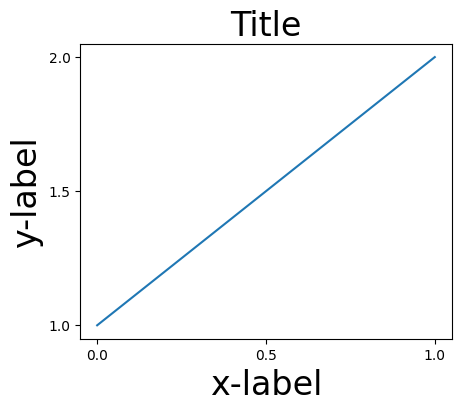

In [93]:
fig, ax = plt.subplots(layout="constrained")
example_plot(ax, fontsize=24)

In [94]:
# Multiple subplots: notice how labels of different Axes overlap each other

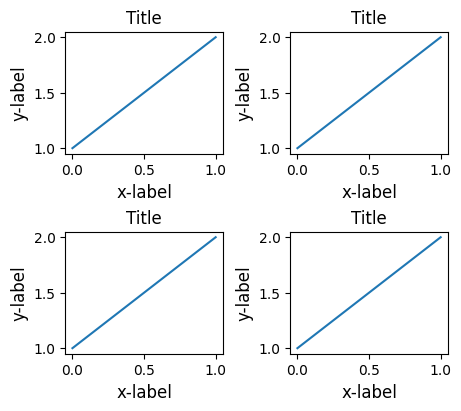

In [95]:
# Remedy this by using layout="constrained"
# Now the labels are clear!
fig, axs = plt.subplots(2, 2, layout="constrained")

for ax in axs.flat:
    example_plot(ax)

## Colorbars

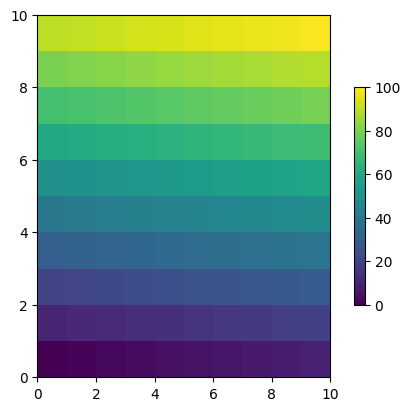

In [96]:
arr = np.arange(100).reshape((10, 10))
norm = mcolors.Normalize(vmin=0.0, vmax=100.0)

# This makes all pcolormesh calls consistent:
pc_kwargs = {
    "rasterized": True,
    "cmap": "viridis",
    "norm": norm,
}

fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")

# Create a pseudo-color plot, with a non-regular rectangular grid
im = ax.pcolormesh(arr, **pc_kwargs)
fig.colorbar(im, ax=ax, shrink=0.6)

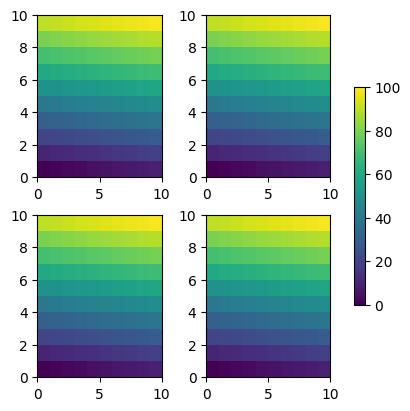

In [97]:
fig, axs = plt.subplots(2, 2, figsize=(4, 4), layout="constrained")

for ax in axs.flat:
    im = ax.pcolormesh(arr, **pc_kwargs)

# For a list of Axes objects, space is taken from the specified Axes:
fig.colorbar(im, ax=axs, shrink=0.6)

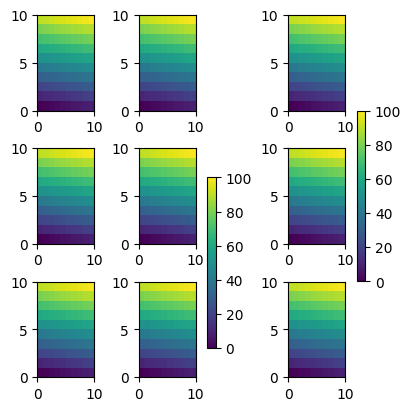

In [98]:
fig, axs = plt.subplots(3, 3, figsize=(4, 4), layout="constrained")

for ax in axs.flat:
    im = ax.pcolormesh(arr, **pc_kwargs)

# Here we specify a list of Axes from a grid of Axes (axs)
fig.colorbar(im, ax=axs[1:, 1], shrink=0.8)
fig.colorbar(im, ax=axs[:, -1], shrink=0.6)

## Suptitle

Text(0.5, 0.98, 'Big Suptitle')

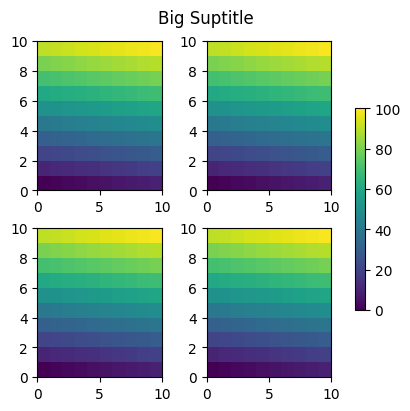

In [99]:
fig, axs = plt.subplots(2, 2, figsize=(4, 4), layout="constrained")

for ax in axs.flat:
    im = ax.pcolormesh(arr, **pc_kwargs)

fig.colorbar(im, ax=axs, shrink=0.6)
fig.suptitle("Big Suptitle")

## Legends

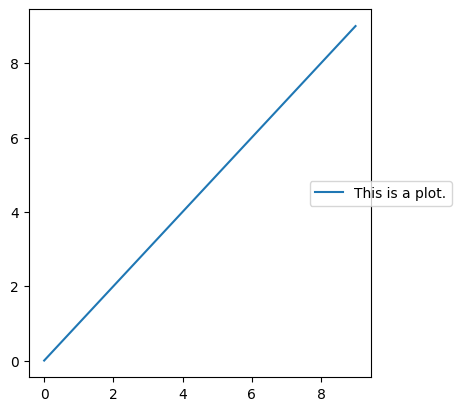

In [100]:
fig, ax = plt.subplots(layout="constrained")
ax.plot(np.arange(10), label="This is a plot.")
ax.legend(loc="center left", bbox_to_anchor=(0.8, 0.5))

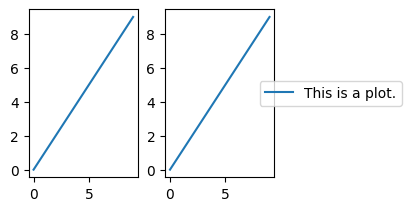

In [101]:
# Stealing space from the subplot layout
fig, axs = plt.subplots(1, 2, figsize=(4, 2), layout="constrained")
axs[0].plot(np.arange(10))
axs[1].plot(np.arange(10), label="This is a plot.")
axs[1].legend(loc="center left", bbox_to_anchor=(0.8, 0.5))

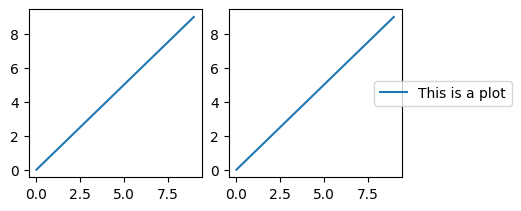

In [102]:
# Preserving the subplot layout (NOT stealing space)
fig, axs = plt.subplots(1, 2, figsize=(4, 2), layout="constrained")

axs[0].plot(np.arange(10))
axs[1].plot(np.arange(10), label="This is a plot")
leg = axs[1].legend(loc="center left", bbox_to_anchor=(0.8, 0.5))
leg.set_in_layout(False)

# Trigger a draw so that constrained layout is executed once
# before we turn it off when printing...
fig.canvas.draw()

# We want the legend included in the bbox_inches="tight" calcs.
leg.set_in_layout(True)

# We don't want the layout to change at this point.
fig.set_layout_engine("none")

try:
    fig.savefig("constrained_layout_1b.png", bbox_inches="tight", dpi=100)
except FileNotFoundError:
    # This allows the script to keep going if run interactively
    # and the directory above doesn't exist.
    pass

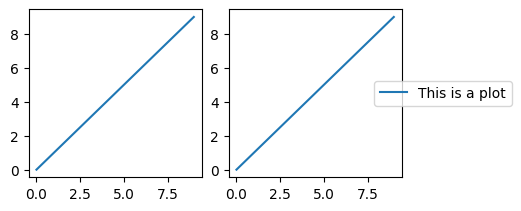

In [103]:
# Or use the legend method of figure:
fig, axs = plt.subplots(1, 2, figsize=(4, 2), layout="constrained")

axs[0].plot(np.arange(10))
lines = axs[1].plot(np.arange(10), label="This is a plot")
labels = [l.get_label() for l in lines]
leg = fig.legend(
    lines,
    labels,
    loc="center left",
    bbox_to_anchor=(0.8, 0.5),
    bbox_transform=axs[1].transAxes,
)

try:
    fig.savefig("constrained_layout_2b.png", bbox_inches="tight", dpi=100)
except FileNotFoundError:
    # This allows the script to keep going if run interactively
    # and the directory above doesn't exist.
    pass

## Padding and Spacing

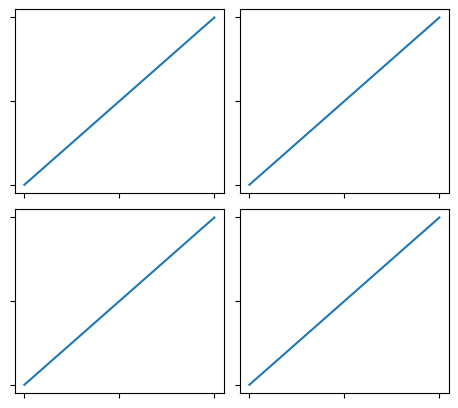

In [104]:
fig, axs = plt.subplots(2, 2, layout="constrained")

for ax in axs.flat:
    example_plot(ax, hide_labels=True)

# w_pad : the minimum space between Axes in the "w"idth direction
# h_pad :                 ""                    "h"eight direction
fig.get_layout_engine().set(w_pad=4 / 72, h_pad=4 / 72, hspace=0, wspace=0)

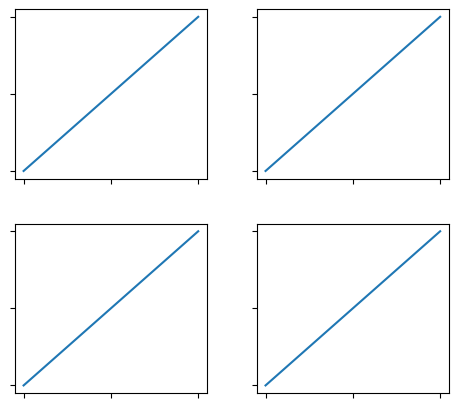

In [105]:
fig, axs = plt.subplots(2, 2, layout="constrained")

for ax in axs.flat:
    example_plot(ax, hide_labels=True)

# hspace/wspace control space between Axes in the height/width direction
fig.get_layout_engine().set(w_pad=4 / 72, h_pad=4 / 72, hspace=0.2, wspace=0.2)

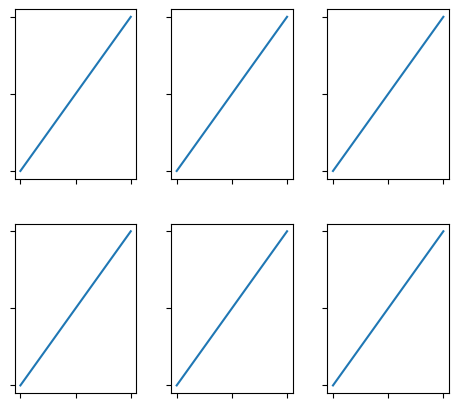

In [106]:
# For more than two columns, wspace is shared between them.
fig, axs = plt.subplots(2, 3, layout="constrained")

for ax in axs.flat:
    example_plot(ax, hide_labels=True)

# hspace/wspace control space between Axes in the height/width direction
fig.get_layout_engine().set(w_pad=4 / 72, h_pad=4 / 72, hspace=0.2, wspace=0.2)

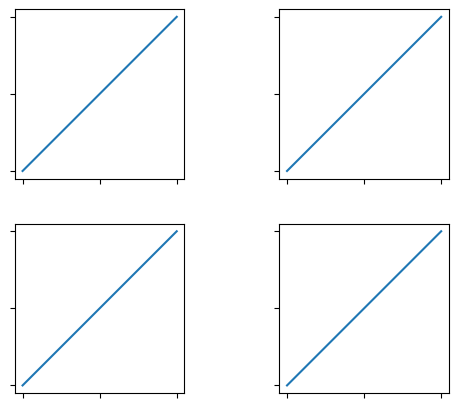

In [107]:
fig, axs = plt.subplots(2, 2, layout="constrained", gridspec_kw={"wspace": 0.4, "hspace": 0.2})

for ax in axs.flat:
    example_plot(ax, hide_labels=True)

# This has no effect because the space set in the "gridspec"
# trumps the space set in "constrained layout".
fig.get_layout_engine().set(w_pad=4 / 72, h_pad=4 / 72, hspace=0.0, wspace=0.0)

### Spacing with Colorbars

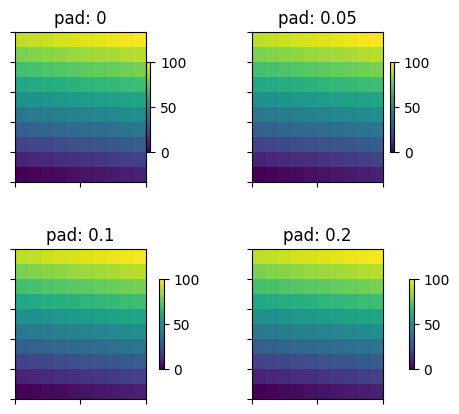

In [108]:
fig, axs = plt.subplots(2, 2, layout="constrained")
pads = [0, 0.05, 0.1, 0.2]

for pad, ax in zip(pads, axs.flat):
    pc = ax.pcolormesh(arr, **pc_kwargs)
    fig.colorbar(pc, ax=ax, shrink=0.6, pad=pad)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(f"pad: {pad}")

fig.get_layout_engine().set(w_pad=2 / 72, h_pad=2 / 72, hspace=0.2, wspace=0.2)

## rcParams

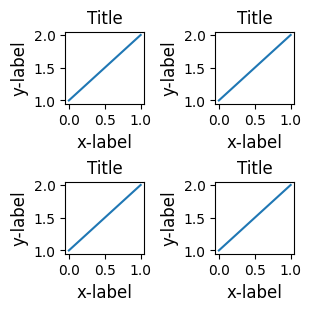

In [109]:
plt.rcParams["figure.constrained_layout.use"] = True
fig, axs = plt.subplots(2, 2, figsize=(3, 3))

for ax in axs.flat:
    example_plot(ax)

## Use with GridSpec

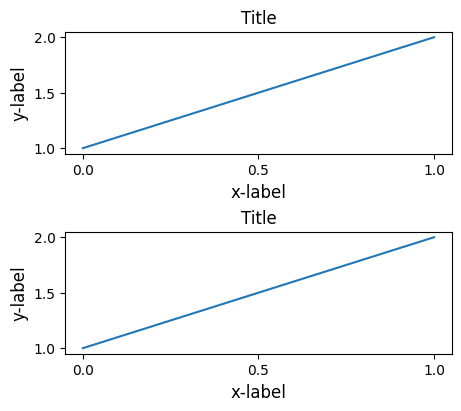

In [110]:
plt.rcParams["figure.constrained_layout.use"] = False
fig = plt.figure(layout="constrained")

gs1 = gridspec.GridSpec(2, 1, figure=fig)
ax1 = fig.add_subplot(gs1[0])
ax2 = fig.add_subplot(gs1[1])

example_plot(ax1)
example_plot(ax2)

Text(0.5, 0, 'x-label')

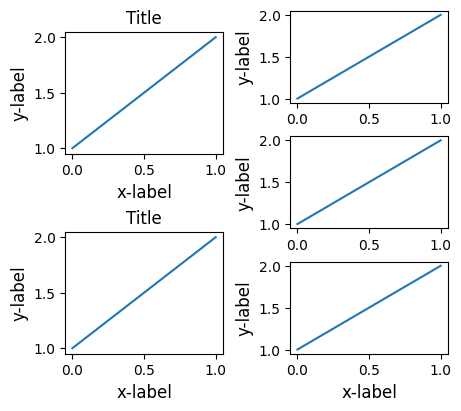

In [111]:
# Complicated gridspec layouts
fig = plt.figure(layout="constrained")

gs0 = fig.add_gridspec(1, 2)
gs1 = gs0[0].subgridspec(2, 1)

ax1 = fig.add_subplot(gs1[0])
ax2 = fig.add_subplot(gs1[1])

example_plot(ax1)
example_plot(ax2)

gs2 = gs0[1].subgridspec(3, 1)

for ss in gs2:
    ax = fig.add_subplot(ss)
    example_plot(ax)
    ax.set_title("")
    ax.set_xlabel("")

# This refers to the last of the three Axes created above.
ax.set_xlabel("x-label", fontsize=12)

Text(0.5, 0.98, 'Overlapping Gridspecs')

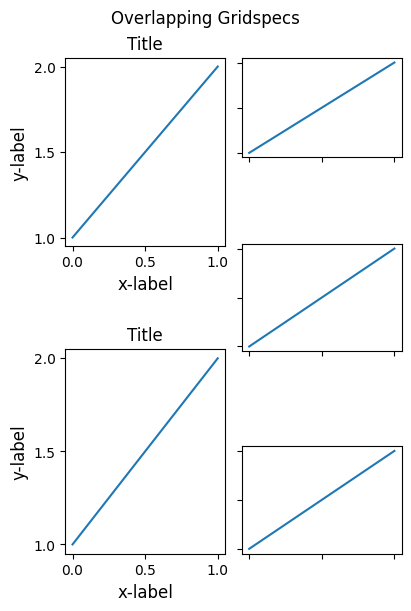

In [112]:
# Make the left and right columns to have the same vertical extent (to line up)
fig = plt.figure(figsize=(4, 6), layout="constrained")

gs0 = fig.add_gridspec(6, 2)
ax1 = fig.add_subplot(gs0[:3, 0])
ax2 = fig.add_subplot(gs0[3:, 0])

example_plot(ax1)
example_plot(ax2)

ax = fig.add_subplot(gs0[0:2, 1])
example_plot(ax, hide_labels=True)
ax = fig.add_subplot(gs0[2:4, 1])
example_plot(ax, hide_labels=True)
ax = fig.add_subplot(gs0[4:, 1])
example_plot(ax, hide_labels=True)

fig.suptitle("Overlapping Gridspecs")

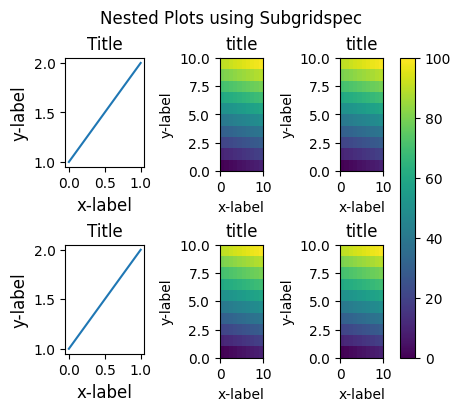

In [113]:
# Here we use two gridspecs so that the colorbar only pertains to one set of pcolors
fig = plt.figure(layout="constrained")

gs0 = fig.add_gridspec(1, 2, figure=fig, width_ratios=[1, 2])
gs_left = gs0[0].subgridspec(2, 1)
gs_right = gs0[1].subgridspec(2, 2)

for gs in gs_left:
    ax = fig.add_subplot(gs)
    example_plot(ax)

axs = []
for gs in gs_right:
    ax = fig.add_subplot(gs)
    pcm = ax.pcolormesh(arr, **pc_kwargs)
    ax.set_xlabel("x-label")
    ax.set_ylabel("y-label")
    ax.set_title("title")
    axs += [ax]

fig.suptitle("Nested Plots using Subgridspec")
fig.colorbar(pcm, ax=axs)

## Manually Setting Axes Positions

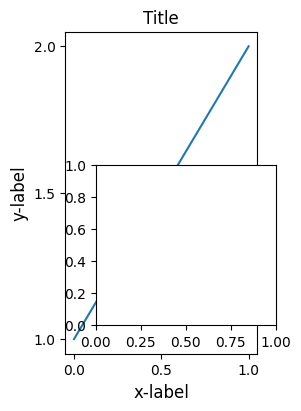

In [114]:
fig, axs = plt.subplots(1, 2, layout="constrained")
example_plot(axs[0], fontsize=12)
axs[1].set_position([0.2, 0.2, 0.4, 0.4])

## Grids of Fixed Aspect-Ratio Axes: "Compressed" Layout

Text(0.5, 0.98, "fixed-aspect plots, layout='constrained'")

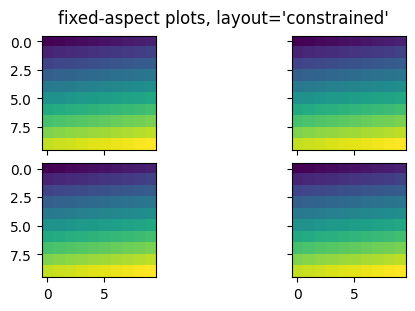

In [115]:
fig, axs = plt.subplots(2, 2, figsize=(5, 3), sharex=True, sharey=True, layout="constrained")

for ax in axs.flat:
    ax.imshow(arr)

fig.suptitle("fixed-aspect plots, layout='constrained'")

Notice in the above that although the Axes are square, the figure is quite wide thus leaving horizontal gap.

To close the gaps, use **compressed** layout.

Text(0.5, 0.98, "fixed-aspect plots, layout='compressed'")

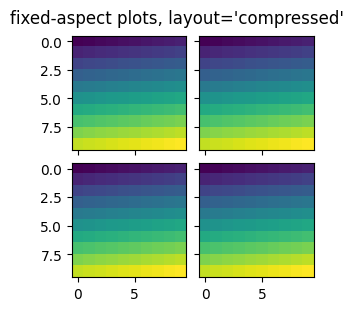

In [116]:
fig, axs = plt.subplots(2, 2, figsize=(5, 3), sharex=True, sharey=True, layout="compressed")

for ax in axs.flat:
    ax.imshow(arr)

fig.suptitle("fixed-aspect plots, layout='compressed'")

## Manually Turning Off Constrained Layout

Do the initial drawing and the call `fig.set_layout_engine("none")`

## Limitations
### Incompatible Functions

Text(0.5, 0.98, 'Homogeneous nrows, ncols')

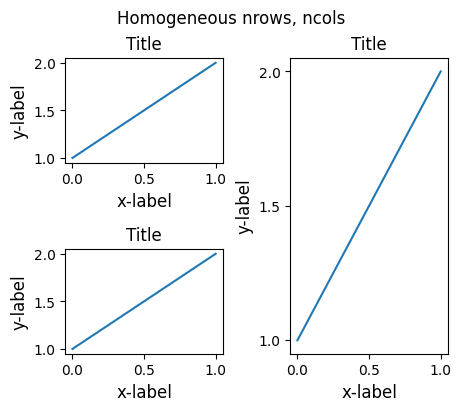

In [117]:
fig = plt.figure(layout="constrained")

ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 3)

# Third Axes that spans both rows in second column
ax3 = plt.subplot(2, 2, (2, 4))

example_plot(ax1)
example_plot(ax2)
example_plot(ax3)

plt.suptitle("Homogeneous nrows, ncols")

# Tight Layout Guide